# Projet Machine Learning - Notebook Python

Ce deuxième notebook se concentre sur la prédiction en Python des variables *Heart_Disease_Risk* et *Cholesterol_LDL*. Pour garder une logique commune dans tout notre projet, nous avons utilisé exactement le même nettoyage de données que dans notre notebook réalisé sous R  dans la partie analyse exploratoire des données. Comme les choix de préparation sont identiques, nous ne les expliquerons pas à nouveau ici ; vous pouvez retrouver tous les détails dans l'autre notebook.

# Modélisation Prédictive : Heart Disease Risk 

## 1. Imports et chargement des données

In [ ]:
# Manipulation de données
import pandas as pd
import numpy as np
import math
from itertools import cycle

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — preprocessing & sélection de modèle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Sklearn — modèles linéaires
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression, lasso_path

# Sklearn — arbres
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

# Sklearn — SVM
from sklearn.svm import SVC, SVR

# Sklearn — ensembles
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Sklearn — réseaux de neurones
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Sklearn — métriques
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

# Chargement du jeu de données
data = pd.read_csv('healthcare_synthetic_data.csv')
print(f'Dimensions initiales : {data.shape}')
data.head()


Dimensions initiales : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 2. Préparation des données

Les transformations ci-dessous sont identiques à celles de l'analyse exploratoire :
- `sqrt(BMI)` et `sqrt(Weight_kg)` : asymétrie positive modérée justifiant une transformation racine carrée
- `sqrt(Fasting_Blood_Sugar)` et `log(Height_cm)` : même justification
- `Stress_Level` et `Sleep_Hours` : traités comme catégoriels 


In [2]:
# Transformations
data['SBMI']                 = np.sqrt(data['BMI'])
data['SWeight']              = np.sqrt(data['Weight_kg'])
data['S_Fasting_Blood_Sugar'] = np.sqrt(data['Fasting_Blood_Sugar'])
data['L_Height_cm']          = np.log(data['Height_cm'])

# Suppression des variables originales remplacées et de l'identifiant 
data = data.drop(columns=['Patient_ID', 'BMI', 'Weight_kg', 'Fasting_Blood_Sugar', 'Height_cm'])

# Encodage des variables catégorielles 
cat_vars = ['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours']

for var in cat_vars:
    data[var] = data[var].astype('category')

# Renommage du genre pour lisibilité 
gender_map = {0: 'Female', 1: 'Male'}
data['Gender'] = data['Gender'].map(gender_map).astype('category')

# Heart_Disease_Risk est déjà en 0/1 dans les données 
data['Heart_Disease_Risk'] = data['Heart_Disease_Risk'].astype('category')

print('--- Types des variables ---')
print(data.dtypes)
print(f'\nValeurs manquantes : {data.isnull().sum().sum()}')


--- Types des variables ---
Age                           int64
Gender                     category
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level               category
Sleep_Hours                category
Heart_Disease_Risk         category
SBMI                        float64
SWeight                     float64
S_Fasting_Blood_Sugar       float64
L_Height_cm                 float64
dtype: object

Valeurs manquantes : 0


### 2.1 Construction de la matrice de features

On applique `pd.get_dummies` avec `drop_first=True` sur toutes les variables catégorielles (sauf la cible) pour éviter la multicolinéarité parfaite.  
Les variables quantitatives transformées sont concaténées directement.


In [3]:
# Encodage one-hot (drop_first=True pour éviter la colinéarité parfaite)
qual_cols = ['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption',
             'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours']

df_dummies = pd.get_dummies(data[qual_cols], drop_first=True)

# Variables quantitatives (transformées + originales conservées)
quant_cols = ['SBMI', 'SWeight', 'S_Fasting_Blood_Sugar', 'L_Height_cm', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL']

df_quant = data[quant_cols]

X = pd.concat([df_dummies, df_quant], axis=1)
y = data['Heart_Disease_Risk'].astype(int)

print(f'Nombre de features : {X.shape[1]}')
print(f'Features : {list(X.columns)}')
print()
vc = y.value_counts()
print(f'Distribution de la cible :')
print(f'  Classe 0 (faible risque) : {vc[0]} ({vc[0]/len(y)*100:.1f}%)')
print(f'  Classe 1 (risque élevé)  : {vc[1]} ({vc[1]/len(y)*100:.1f}%)')
print(f'\n→ Déséquilibre modéré (56% / 44%) : pas de rééchantillonnage nécessaire.')


Nombre de features : 33
Features : ['Gender_Male', 'Smoking_Status_1', 'Family_History_1', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Physical_Activity_Level_1', 'Physical_Activity_Level_2', 'Physical_Activity_Level_3', 'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10', 'SBMI', 'SWeight', 'S_Fasting_Blood_Sugar', 'L_Height_cm', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL']

Distribution de la cible :
  Classe 0 (faible risque) : 8460 (56.4%)
  Classe 1 (risque élevé)  : 6540 (43.6%)

→ Déséquilibre modéré (56% / 44%) : pas de rééchantillonnage nécessaire.


## 3. Division train/test et normalisation

### 3.1 Pourquoi cette étape est-elle nécessaire ?

L'évaluation d'un modèle sur ses propres données d'entraînement introduit un biais d'optimisme. La création d'un jeu de test (20 %) garantit une évaluation hors échantillon rigoureuse, indispensable pour simuler de nouvelles données, valider la capacité de généralisation et écarter tout risque de sur-apprentissage. De plus, l'option stratify=y préserve la distribution initiale des classes (≈56/44) dans les deux sous-ensembles, évitant ainsi un biais de représentativité.


In [4]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(f'Apprentissage : {X_train.shape[0]} obs. '
      f'({y_train.mean()*100:.1f}% risque élevé)')
print(f'Test          : {X_test.shape[0]} obs. '
      f'({y_test.mean()*100:.1f}% risque élevé)')


Apprentissage : 12000 obs. (43.6% risque élevé)
Test          : 3000 obs. (43.6% risque élevé)


### 3.2 Normalisation

La normalisation des variables est requise pour garantir la convergence des modèles basés sur l'optimisation ou le calcul de distances (Régression Logistique, SVM, Réseaux de Neurones). À l'inverse, les modèles arborescents (Random Forest, Boosting) n'en nécessitent pas, de par leur invariance aux transformations monotones. D'un point de vue méthodologique, la transformation (StandardScaler) est calibrée exclusivement sur les données d'entraînement afin d'isoler totalement l'ensemble de test et de prévenir toute fuite d'information.


In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)       

print('Normalisation appliquée : mean≈0, std≈1 sur chaque feature.')
print(f'Vérification : moyenne sur X_train_sc ≈ '
      f'{X_train_sc.mean():.4f} (attendu : ~0)')


Normalisation appliquée : mean≈0, std≈1 sur chaque feature.
Vérification : moyenne sur X_train_sc ≈ 0.0000 (attendu : ~0)


## 4. Modélisation

### 4.0 Fonction d'évaluation centralisée

Le calcul des performances est centralisé afin de garantir une comparaison stricte et impartiale entre les différents algorithmes. L'évaluation s'appuie sur ces trois critères principaux :

--> Accuracy : indicateur de la performance prédictive globale.

--> F1-score : métrique de robustesse, privilégiée pour limiter l'impact d'un éventuel déséquilibre entre les classes.

--> AUC-ROC : permet d'évaluer le pouvoir discriminant du modèle indépendamment du seuil de décision.


In [6]:
resultats_test = {}

def evaluer_modele(nom, modele, X_eval, y_eval, afficher=True):
    
    y_pred  = modele.predict(X_eval)
    y_proba = modele.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_eval, y_pred)
    f1  = f1_score(y_eval, y_pred, average='macro')
    auc_val = roc_auc_score(y_eval, y_proba)

    resultats_test[nom] = {
        'Accuracy': acc,
        'F1-macro': f1,
        'AUC-ROC' : auc_val,
        'modele'  : modele,
        'X_eval'  : X_eval,
        'y_proba' : y_proba
    }

    if afficher:
        print(f'[{nom}]')
        print(f'  Accuracy = {acc:.4f}  |  F1-macro = {f1:.4f}  |  AUC-ROC = {auc_val:.4f}')
    return acc, f1, auc_val


Cette fonction centralise l'évaluation des modèles sur l'échantillon de test. Elle calcule et archive un triptyque de métriques (Accuracy, F1-macro et AUC-ROC) afin de garantir une comparaison rigoureuse et cohérente entre les différentes architectures testées.

### 4.1 Régression Logistique (avec/sans pénalisation)

La régression logistique estime la probabilité conditionnelle du risque via la fonction sigmoïde : $P(Y=1|X=x) = \sigma(\langle\beta,x\rangle)$. Afin d'optimiser le compromis biais-variance et d'atténuer l'impact de la multicolinéarité, le modèle est soumis à une recherche d'hyperparamètres par validation croisée. Cette étape évalue trois schémas de régularisation : l'absence de pénalité, la norme $L_2$ (Ridge) et la norme $L_1$ (Lasso). L'intensité de cette régularisation est pilotée par l'hyperparamètre $C$ (où $C = \frac{1}{\lambda}$).


In [7]:
param_grid_log = {
    'penalty': ['l1', 'l2', None],
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['saga']  
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_log, cv=5, scoring='roc_auc', n_jobs=-1
)
log_grid.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {log_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {log_grid.best_score_:.4f}')
print()
evaluer_modele('Logistique', log_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
AUC-ROC en validation croisée (cv=5) : 0.8069

[Logistique]
  Accuracy = 0.7357  |  F1-macro = 0.7272  |  AUC-ROC = 0.8025


(0.7356666666666667, 0.7272499329589737, 0.8025444437214884)

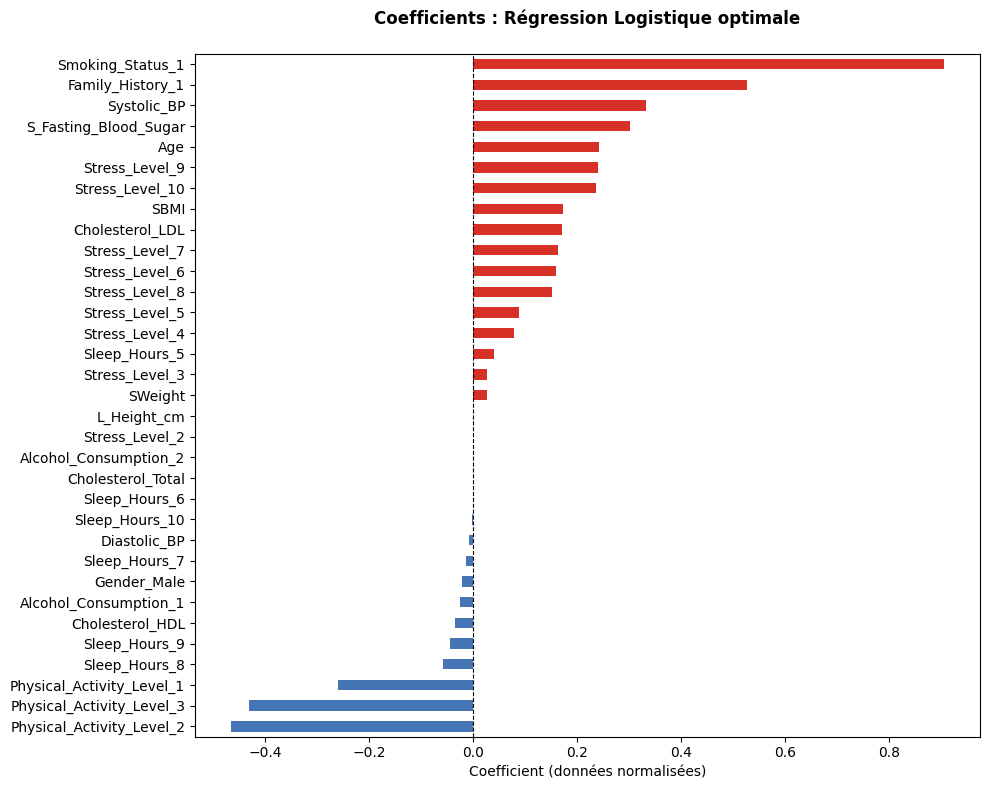

Nombre de coefficients non nuls : 28/33


In [8]:
# Coefficients du meilleur modèle de regression logistique 
best_log = log_grid.best_estimator_
coeffs = pd.Series(best_log.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coeffs]
coeffs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Coefficients : Régression Logistique optimale\n', fontweight='bold')
ax.set_xlabel('Coefficient (données normalisées)')
plt.tight_layout()
plt.show()

print(f'Nombre de coefficients non nuls : '
      f'{(np.abs(best_log.coef_[0]) > 1e-6).sum()}/{len(X.columns)}')


L'analyse des coefficients normalisés offre une lecture directe et transparente des variables influençant la prédiction. Visuellement, le modèle isole le tabagisme et l'hérédité comme les principaux vecteurs de risque cardiovasculaire, marqués par les poids positifs les plus élevés. À l'inverse, l'activité physique se distingue nettement comme le facteur protecteur majeur, ses différents niveaux affichant les coefficients négatifs les plus prononcés. Le graphique met également en lumière des effets de palier pertinents, notamment pour le stress, dont seuls les niveaux extrêmes (9 et 10) aggravent significativement l'estimation du risque.

### 4.2 Arbre de Décision Optimal (CART)

L'arbre de décision segmente récursivement l'espace des variables via des règles binaires explicites, offrant une transparence totale. Par nature, cet algorithme est invariant aux changements d'échelle et ne nécessite donc aucune normalisation. Pour contrôler sa complexité et éviter le sur-apprentissage, l'optimisation s'est concentrée sur la profondeur de l'arbre (max_depth), la taille minimale des feuilles (min_samples_leaf) et la métrique de pureté des scissions (criterion, Gini ou Entropie).

In [9]:
param_grid_tree = {
    'max_depth'        : [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf' : [5, 10, 20, 50],
    'criterion'        : ['gini', 'entropy']
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, cv=5, scoring='roc_auc', n_jobs=-1
)
# Pas de normalisation pour les arbres de décision
tree_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {tree_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {tree_grid.best_score_:.4f}')
print(f'Profondeur de l\'arbre optimal : {tree_grid.best_estimator_.get_depth()}')
print(f'Nombre de feuilles : {tree_grid.best_estimator_.get_n_leaves()}')
print()
evaluer_modele('Arbre CART', tree_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 50}
AUC-ROC en validation croisée (cv=5) : 0.7626
Profondeur de l'arbre optimal : 8
Nombre de feuilles : 99

[Arbre CART]
  Accuracy = 0.7070  |  F1-macro = 0.6933  |  AUC-ROC = 0.7641


(0.707, 0.6932570644224143, 0.7640666908856935)

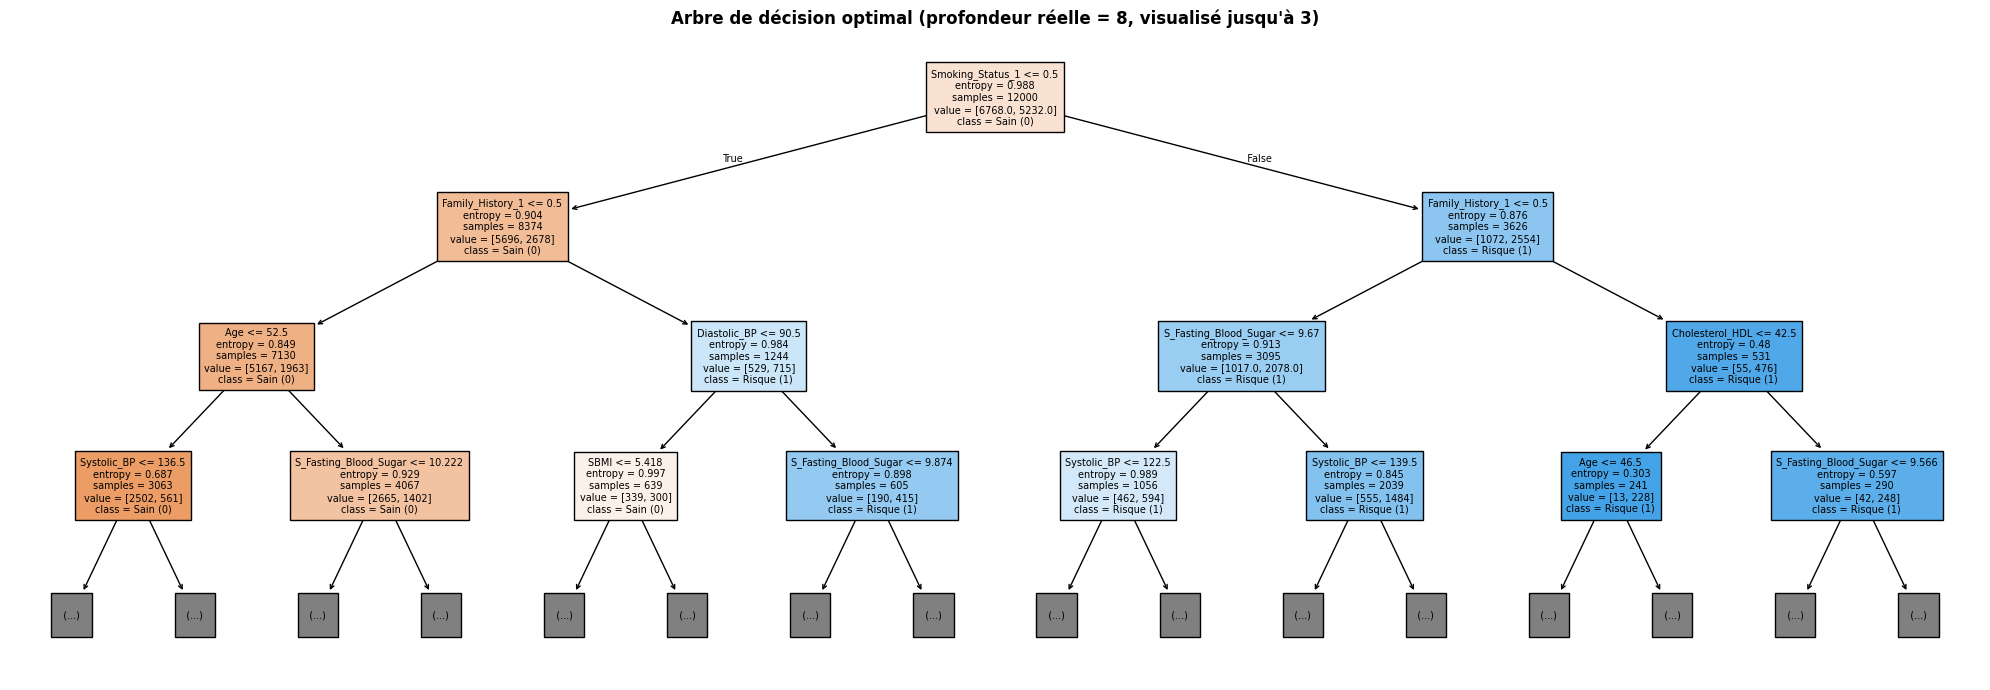

In [10]:
# Visualisation de l'arbre (profondeur limitée à 3 pour la lisibilité)
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    tree_grid.best_estimator_,
    feature_names=list(X.columns),
    class_names=['Sain (0)', 'Risque (1)'],
    filled=True, max_depth=3, fontsize=7, ax=ax
)
ax.set_title(
    f'Arbre de décision optimal '
    f'(profondeur réelle = {tree_grid.best_estimator_.get_depth()}, '
    f'visualisé jusqu\'à 3)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()


L'arbre de décision, ici visualisé sur ses trois premiers niveaux d'interaction, offre une cartographie explicite de la hiérarchie des risques. La scission racine s'opère logiquement sur le tabagisme (Smoking_Status_1), confirmant son statut de discriminant principal, immédiatement suivi par l'hérédité (Family_History_1) pour segmenter davantage les sous-populations. Visuellement, la topologie de l'arbre révèle une forte asymétrie : la partie droite, qui regroupe les patients cumulant ces facteurs, bascule très rapidement vers des nœuds classés à risque (teintes bleutées) et affine ses règles via des biomarqueurs comme la glycémie ou le cholestérol HDL. À l'inverse, la section gauche concentre des profils majoritairement sains (teintes orangées), où l'âge et la tension artérielle interviennent plus tardivement pour nuancer la prédiction. En explicitant ces cascades de conditions, le modèle arborescent illustre parfaitement les interactions non linéaires entre les variables cliniques et confirme la robustesse des signaux identifiés lors de la régression logistique, le tout via une matrice de décision directement lisible.

### 4.3 SVM — Support Vector Machine

L'optimisation du modèle SVM s'appuie sur la comparaison de deux géométries de séparation. Le noyau linéaire recherche un hyperplan de décision strict dans l'espace d'origine des variables, tandis que le noyau gaussien (RBF) recourt au kernel trick pour projeter les données dans un espace de Hilbert de dimension infinie, autorisant ainsi l'apprentissage de frontières non linéaires complexes. Afin d'ajuster le compromis biais-variance, la validation croisée optimise conjointement le type de noyau, la constante de régularisation C (qui contrôle la tolérance aux erreurs de classification sur la marge) et l'hyperparamètre gamma, qui définit le rayon d'influence géométrique du noyau RBF.


In [ ]:
param_grid_svm = {
    'kernel': ['linear', 'rbf'],  
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']   # ignoré si kernel='linear'
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=5, scoring='roc_auc', n_jobs=-1
)
svm_grid.fit(X_train_sc, y_train)

best_k = svm_grid.best_params_['kernel']
print(f'Meilleurs hyperparamètres : {svm_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {svm_grid.best_score_:.4f}')
print()
if best_k == 'rbf':
    print('→ Noyau RBF retenu : les données ne sont pas linéairement séparables,')
    print('  le noyau gaussien permet des frontières non-linéaires via le kernel trick.')
else:
    print('→ Noyau linéaire retenu : les données sont quasi linéairement séparables,')
    print('  cohérent avec les bonnes performances de la régression logistique.')
print()
evaluer_modele('SVM', svm_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
AUC-ROC en validation croisée (cv=5) : 0.8034

→ Noyau linéaire retenu : les données sont quasi linéairement séparables,
  cohérent avec les bonnes performances de la régression logistique.

[SVM]
  Accuracy = 0.7227  |  F1-macro = 0.7134  |  AUC-ROC = 0.7995


(0.7226666666666667, 0.7133801846493041, 0.7994660066078181)

### 4.4 Forêt Aléatoire (Random Forest)

L'algorithme des Forêts Aléatoires (Random Forest) agrège un ensemble d'arbres de décision, chacun construit sur un échantillon bootstrap indépendant. L'injection d'un double aléa, combinant ce rééchantillonnage à la sélection aléatoire d'un sous-espace de $m$ variables à chaque scission, permet de décorréler les estimateurs et de réduire drastiquement la variance globale du modèle sans en dégrader le biais. Pour maximiser cette capacité de généralisation, la validation croisée optimise simultanément la taille de la forêt (n_estimators), la profondeur structurelle (max_depth), la régularisation terminale (min_samples_leaf) ainsi que la dimension du sous-espace de recherche nodal (max_features, usuellement fixé à $\sqrt{p}$).

In [12]:
param_grid_rf = {
    'n_estimators'    : [100, 300],
    'max_depth'       : [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features'    : ['sqrt']   
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {rf_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {rf_grid.best_score_:.4f}')
print()
evaluer_modele('Random Forest', rf_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 300}
AUC-ROC en validation croisée (cv=5) : 0.7903

[Random Forest]
  Accuracy = 0.7267  |  F1-macro = 0.7147  |  AUC-ROC = 0.7885


(0.7266666666666667, 0.7147165883258317, 0.7885236153584778)

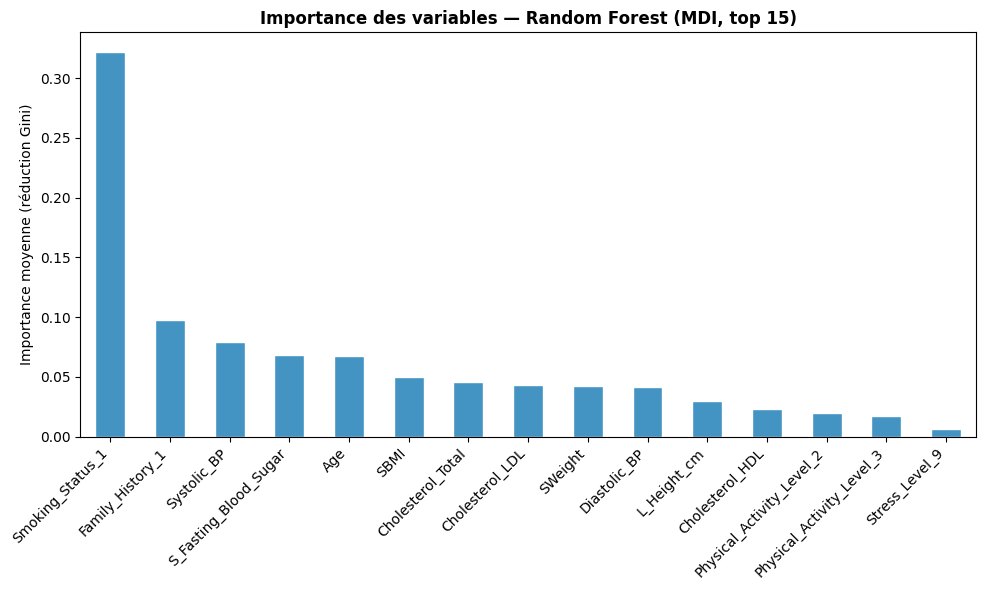

In [13]:
best_rf = rf_grid.best_estimator_
imp_rf = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
imp_rf.plot(kind='bar', ax=ax, color='#4393c3', edgecolor='white')
ax.set_title('Importance des variables — Random Forest (MDI, top 15)', fontweight='bold')
ax.set_ylabel('Importance moyenne (réduction Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


L'analyse de l'importance des variables par réduction d'impureté de Gini met en évidence la prépondérance du tabagisme dans la structuration de la forêt, avec un poids décisionnel nettement supérieur aux autres prédicteurs. Un second socle d'information se dessine ensuite autour de l'hérédité, de la pression artérielle et de la glycémie, confirmant que le modèle s'appuie sur des piliers cliniques fondamentaux. La forte similitude entre cette hiérarchie et celle établie par la régression logistique souligne la stabilité du signal extrait : les facteurs de risque identifiés restent constants malgré le changement d'architecture algorithmique, ce qui valide la robustesse de l'analyse et la fiabilité des variables sélectionnées.

### 4.5 Gradient Boosting (GradientBoostingClassifier)

Le Gradient Boosting repose sur l'agrégation séquentielle d'arbres de décision ajustés sur le gradient négatif de la fonction de perte (pseudo-résidus). Conformément aux préconisations théoriques, l'introduction d'un learning rate ($\nu$) permet de pondérer la contribution de chaque itéré pour stabiliser la convergence et limiter le risque d'overfitting. La recherche d'hyperparamètres par validation croisée optimise ainsi le nombre d'itérations ($M$), la profondeur des arbres ($J$) et le taux de sous-échantillonnage ($\eta$).



In [ ]:
param_grid_gb = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1],       
    'max_depth'    : [3, 4, 5],         
    'subsample'    : [0.8, 1.0]        
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {gb_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {gb_grid.best_score_:.4f}')
print()
evaluer_modele('Gradient Boosting', gb_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC-ROC en validation croisée (cv=5) : 0.7992

[Gradient Boosting]
  Accuracy = 0.7250  |  F1-macro = 0.7162  |  AUC-ROC = 0.7961


(0.725, 0.7162436250834214, 0.7960938686099724)

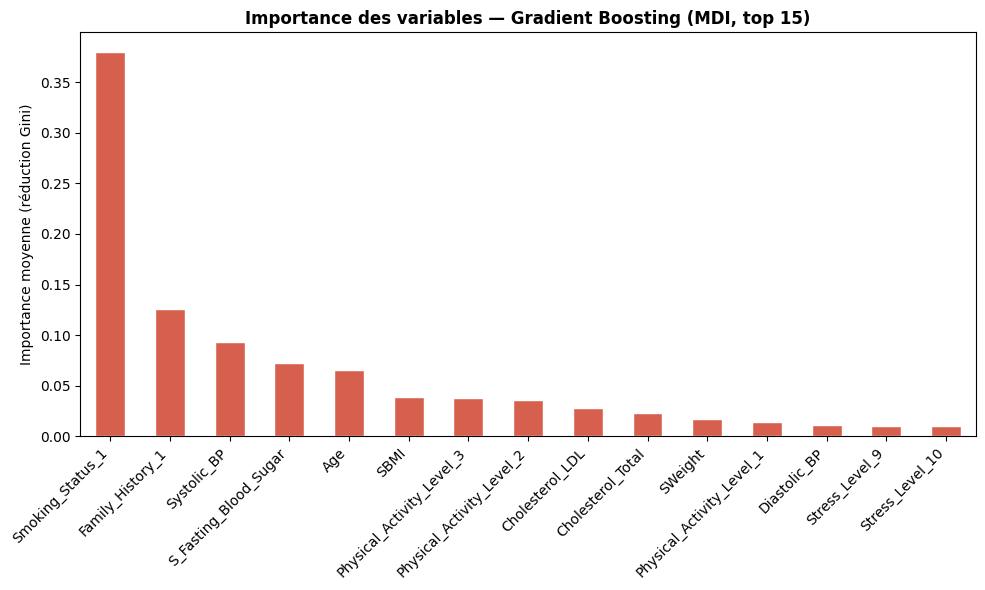

In [15]:
# moyenne des réductions d'impureté (Gini) induites par chaque variable
imp_gb = pd.Series(
    gb_grid.best_estimator_.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
imp_gb.plot(kind='bar', ax=ax, color='#d6604d', edgecolor='white')
ax.set_title('Importance des variables — Gradient Boosting (MDI, top 15)', fontweight='bold')
ax.set_ylabel('Importance moyenne (réduction Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Le Gradient Boosting confirme et accentue la prépondérance du tabagisme comme levier prédictif majeur du risque cardiovasculaire. La hiérarchie des variables reste cohérente avec les modèles précédents, plaçant l'hérédité, la pression systolique et la glycémie au cœur de la décision. Cette stabilité des importances, observée à travers des paradigmes d'apprentissage différents (séquentiel pour le boosting vs parallèle pour la forêt), démontre que le signal statistique est particulièrement robuste et peu sensible au choix de l'architecture algorithmique.

### 4.6 Réseau de Neurones (MLP)

Le Perceptron Multicouche (MLP) minimise l'entropie croisée par rétropropagation pour estimer les probabilités de classe. L'optimisation porte sur l'architecture des couches cachées, la fonction d'activation et la régularisation $L_2$ (alpha).


In [16]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (64, 32)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [1e-4, 1e-3, 1e-2]
}

mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=500,
        early_stopping=True,   # arrête si la loss de validation ne baisse plus
        n_iter_no_change=15,   # patience de 15 itérations sans amélioration
        random_state=42
    ),
    param_grid_mlp, cv=5, scoring='roc_auc', n_jobs=-1
)
mlp_grid.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {mlp_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {mlp_grid.best_score_:.4f}')
print()
evaluer_modele('Réseau de Neurones', mlp_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (64,)}
AUC-ROC en validation croisée (cv=5) : 0.8022

[Réseau de Neurones]
  Accuracy = 0.7347  |  F1-macro = 0.7254  |  AUC-ROC = 0.7987


(0.7346666666666667, 0.7253687511040452, 0.7986504218448391)

## 5. Comparaison des modèles

### 5.1 Tableau récapitulatif (métriques sur l'échantillon TEST)

L'évaluation finale repose exclusivement sur l'échantillon de test afin de garantir une estimation non biaisée de la généralisation sur des données inédites. Les procédures de validation croisée ont été strictement réservées à la phase d'optimisation des hyperparamètres et au réglage fin des modèles.


In [17]:
noms = ['Logistique', 'Arbre CART', 'SVM',
        'Random Forest', 'Gradient Boosting', 'Réseau de Neurones']

df_recap = pd.DataFrame({
    'Modèle'   : noms,
    'Accuracy' : [resultats_test[n]['Accuracy']  for n in noms],
    'F1-macro' : [resultats_test[n]['F1-macro']  for n in noms],
    'AUC-ROC'  : [resultats_test[n]['AUC-ROC']  for n in noms],
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('=' * 58)
print('PERFORMANCES SUR L\'ÉCHANTILLON TEST (n=3 000 patients)')
print('=' * 58)
print(df_recap.to_string(index=False,
      float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))
print()
best_name = df_recap.iloc[0]['Modèle']
best_auc  = df_recap.iloc[0]['AUC-ROC']
print(f'→ Meilleur modèle (AUC-ROC) : {best_name} ({best_auc:.4f})')

# Gain des modèles non-linéaires vs logistique
auc_log = df_recap.loc[df_recap['Modèle']=='Logistique', 'AUC-ROC'].values[0]
auc_best = df_recap.iloc[0]['AUC-ROC']
print(f'Gain AUC (meilleur vs logistique) : +{(auc_best-auc_log)*100:.2f} pts')


PERFORMANCES SUR L'ÉCHANTILLON TEST (n=3 000 patients)
            Modèle  Accuracy  F1-macro  AUC-ROC
        Logistique    0.7357    0.7272   0.8025
               SVM    0.7227    0.7134   0.7995
Réseau de Neurones    0.7347    0.7254   0.7987
 Gradient Boosting    0.7250    0.7162   0.7961
     Random Forest    0.7267    0.7147   0.7885
        Arbre CART    0.7070    0.6933   0.7641

→ Meilleur modèle (AUC-ROC) : Logistique (0.8025)
Gain AUC (meilleur vs logistique) : +0.00 pts


Les performances sur l'échantillon test confirment la robustesse de la régression logistique, qui domine l'ensemble des métriques avec un AUC-ROC de $0,8025$. Malgré leur complexité, le réseau de neurones et les modèles ensemblistes ne parviennent à générer aucun gain prédictif, affichant des scores quasi identiques ou légèrement inférieurs. Cette convergence souligne que le signal de risque est capturé de manière optimale par une frontière de décision linéaire, faisant de la logistique le choix préférentiel pour sa stabilité et sa totale transparence clinique.

### 5.2 Courbes ROC

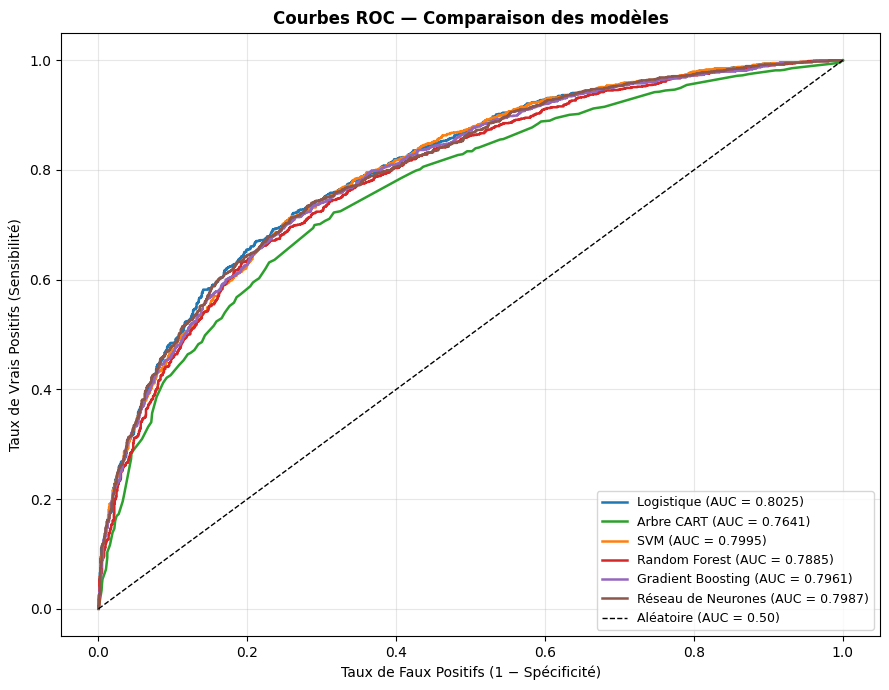

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd','#8c564b']
modeles_roc = [
    ('Logistique',       log_grid.best_estimator_,  X_test_sc),
    ('Arbre CART',       tree_grid.best_estimator_, X_test),
    ('SVM',              svm_grid.best_estimator_,  X_test_sc),
    ('Random Forest',    rf_grid.best_estimator_,   X_test),
    ('Gradient Boosting',gb_grid.best_estimator_,  X_test),
    ('Réseau de Neurones',mlp_grid.best_estimator_, X_test_sc),
]

for (nom, modele, Xev), col in zip(modeles_roc, colors):
    y_p = modele.predict_proba(Xev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_p)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{nom} (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--',lw=1,label='Aléatoire (AUC = 0.50)')
ax.set_xlabel('Taux de Faux Positifs (1 − Spécificité)')
ax.set_ylabel('Taux de Vrais Positifs (Sensibilité)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La comparaison des courbes ROC met en évidence une forte convergence des performances, la majorité des modèles s'agglutinant autour d'un AUC de $0,80$. La Régression Logistique conserve une légère avance ($0,8025$), ses capacités de discrimination étant quasi identiques à celles d'architectures bien plus complexes comme le MLP ou le Gradient Boosting. Cet entrelacement des courbes suggère que la frontière de décision optimale est intrinsèquement simple, rendant les gains issus de la non-linéarité marginaux sur ce jeu de données. Seul l'arbre CART marque un décrochage net, confirmant l'insuffisance d'une segmentation binaire unique pour capturer la finesse des facteurs de risque.

### 5.3 Matrices de confusion des modèles optimaux

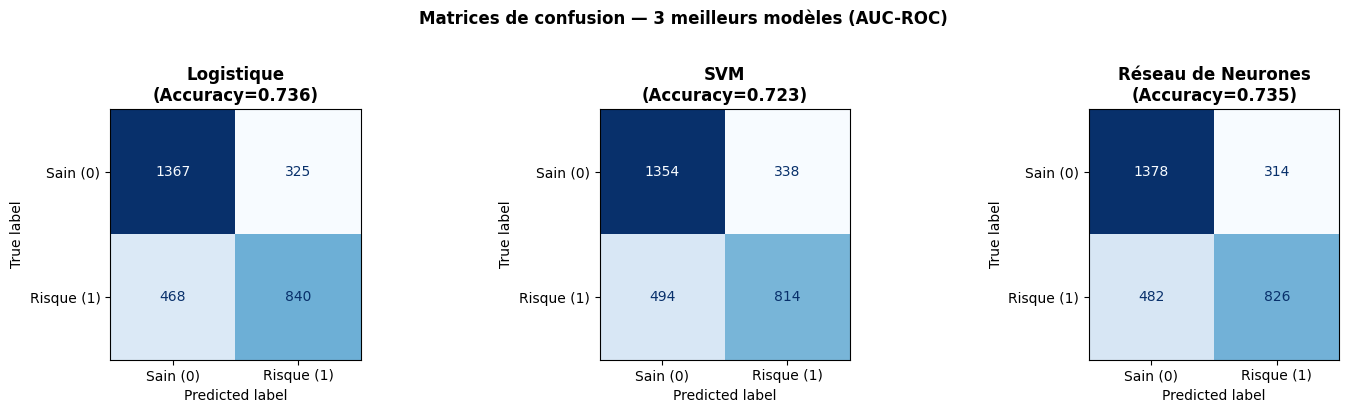

--- Classification report : Logistique ---
              precision    recall  f1-score   support

    Sain (0)       0.74      0.81      0.78      1692
  Risque (1)       0.72      0.64      0.68      1308

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.74      0.73      3000



In [19]:
top3 = df_recap['Modèle'].head(3).tolist()
modeles_map = {
    'Logistique'       : (log_grid.best_estimator_,  X_test_sc),
    'Arbre CART'       : (tree_grid.best_estimator_, X_test),
    'SVM'              : (svm_grid.best_estimator_,  X_test_sc),
    'Random Forest'    : (rf_grid.best_estimator_,   X_test),
    'Gradient Boosting': (gb_grid.best_estimator_,  X_test),
    'Réseau de Neurones': (mlp_grid.best_estimator_, X_test_sc),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nom in zip(axes, top3):
    modele, Xev = modeles_map[nom]
    y_pred = modele.predict(Xev)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sain (0)', 'Risque (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nom}\n(Accuracy={acc:.3f})', fontweight='bold')
plt.suptitle('Matrices de confusion — 3 meilleurs modèles (AUC-ROC)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_nom  = df_recap.iloc[0]['Modèle']
best_mod, best_Xev = modeles_map[best_nom]
print(f'--- Classification report : {best_nom} ---')
print(classification_report(y_test, best_mod.predict(best_Xev),
      target_names=['Sain (0)', 'Risque (1)']))


Les matrices de confusion confirment l'homogénéité des performances : la structure des erreurs est quasi identique entre le modèle linéaire et le réseau de neurones. Le rapport de classification de la Régression Logistique révèle toutefois une asymétrie du rappel : le modèle identifie plus efficacement les sujets sains ($0,81$) que les sujets à risque ($0,64$). Ce déficit de sensibilité souligne que, malgré une précision globale satisfaisante ($74\%$), l'ajustement du seuil de décision reste un levier d'optimisation crucial pour réduire les faux négatifs dans un contexte de diagnostic médical.

## 6. Évaluation et Comparaison des Modèles

### 6.1. Synthèse des performances sur l'échantillon test

L'évaluation finale confirme la hiérarchie établie lors de la validation croisée.

| Modèle | Accuracy | F1-macro | AUC-ROC |
| :--- | :---: | :---: | :---: |
| Logistique | 0.7357 | 0.7272 | 0.8025 |
| Réseau de Neurones | 0.7347 | 0.7254 | 0.7987 |
| SVM | 0.7227 | 0.7134 | 0.7995 |
| Gradient Boosting | 0.7250 | 0.7162 | 0.7961 |
| Random Forest | 0.7267 | 0.7147 | 0.7885 |
| Arbre CART | 0.7070 | 0.6933 | 0.7641 |

Les résultats montrent que la Régression Logistique surpasse les modèles complexes. L'absence de gain significatif via les approches non-linéaires (MLP, Boosting) prouve que la structure du risque cardiaque est essentiellement linéaire dans ce jeu de données.

### 6.2. Analyse discriminante (ROC) et Matrices de confusion
L'étude des courbes ROC montre une saturation des performances autour d'un AUC de $0,80$. La superposition des courbes pour la Logistique, le SVM et le MLP souligne que le plafond de performance est atteint dès le modèle linéaire.

L'examen des matrices de confusion et du rapport de classification révèle toutefois une disparité :
* **Précision globale :** 74 %.
* **Rappel (Sains) :** 0,81.
* **Rappel (Risque) :** 0,64.

Le modèle identifie plus difficilement les patients malades. Dans un contexte clinique, un ajustement du seuil de décision (actuellement à $0,5$) serait impératif pour augmenter la sensibilité et réduire les faux négatifs.

### 6.3. Interprétabilité et Facteurs de Risque
L'avantage décisif de la Régression Logistique réside dans sa transparence totale. L'analyse des coefficients normalisés permet d'isoler les leviers biologiques du risque :

1.  **Vecteurs de risque :** Le tabagisme et l'hérédité dominent largement la prédiction, suivis par la tension systolique.
2.  **Effet protecteur :** L'activité physique se distingue comme le principal facteur de réduction du risque.
3.  **Facteurs neutres :** Le stress n'intervient de manière significative qu'à des niveaux extrêmes (9 et 10).

## 7. Conclusion
Nous retenons la Régression Logistique optimale comme modèle final. Elle offre le meilleur compromis entre puissance prédictive ($AUC = 0.80$) et robustesse. Sa capacité à fournir une explication clinique pour chaque diagnostic en fait l'outil le plus adapté à une intégration dans un protocole d'aide à la décision médicale.


# Modélisation Prédictive : Cholesterol LDL

## Etude Cholesterol LDL

Avant de passer à la prédiction du taux de cholestérol LDL, nous commençons par une analyse uni et bidimensionnelle de cette variable. Cette première partie nous permet de mieux comprendre la distribution des données et les relations entre les variables.

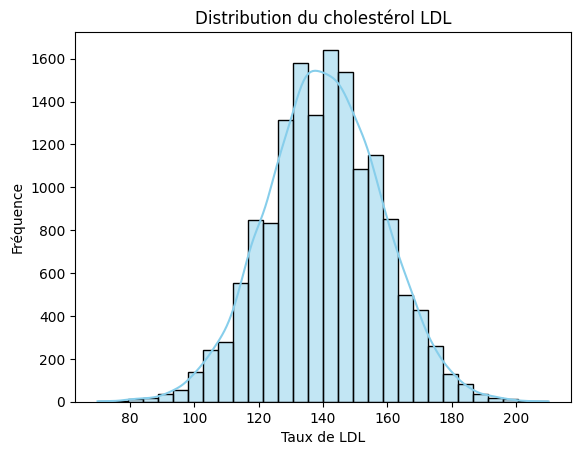

In [20]:
sns.histplot(data['Cholesterol_LDL'], bins=30, kde=True, color='skyblue')
plt.title('Distribution du cholestérol LDL')
plt.xlabel('Taux de LDL')
plt.ylabel('Fréquence')
plt.show()

L'histogramme montre que le taux de cholestérol LDL suit une loi normale, avec une forme en cloche bien symétrique centrée autour de 140. Cette répartition équilibrée indique qu'il y a peu de valeurs extrêmes et que les données sont bien distribuées. C'est un excellent point pour nos modèles de régression, car cela facilite l'apprentissage et permet d'obtenir des prédictions plus stables sans avoir à transformer la variable.

La cellule suivante présente la matrice de corrélation entre les variables quantitatives du jeu de données. Ce graphique nous permet d'identifier rapidement les variables les plus liées au taux de cholestérol LDL.

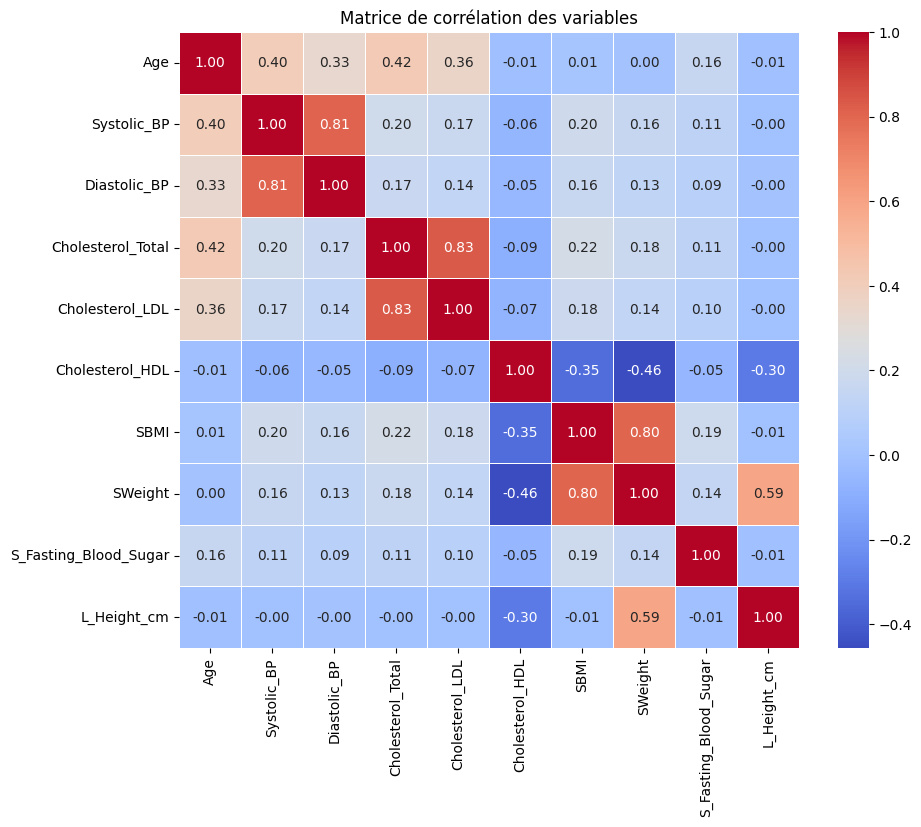

In [21]:
#on séléctionne uniquement les variables quantitatives
corr_matrix = data.select_dtypes(include=['number']).corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de corrélation des variables')
plt.show()

La matrice de corrélation montre que le taux de cholestérol LDL est très fortement lié au Cholesterol_Total ($0.83$), ce qui est logiquement attendu puisque le LDL en est une composante majeure. On observe également une corrélation modérée avec l'âge ($0.36$), suggérant que le taux de LDL tend à augmenter avec les années. En revanche, il n'existe pratiquement aucune relation linéaire avec le cholestérol HDL ou les autres mesures physiques comme le poids ou la taille.

## Préparation des données pour la prédiction du LDL

Nous appliquons les **mêmes transformations** que pour la prédiction du risque cardiaque, afin que la chaîne de pré-traitement soit identique entre les deux études :
- Transformation racine carrée sur `BMI`, `Weight_kg` et `Fasting_Blood_Sugar` (asymétrie positive modérée)
- Transformation logarithmique sur `Height_cm`
- Encodage one-hot des variables qualitatives avec `drop_first=True`

Conformément à la consigne du projet, la variable `Heart_Disease_Risk` est **exclue** des prédicteurs pour cette seconde étude.


In [ ]:
# par les modifications faites dans la section Heart Disease
data = pd.read_csv('healthcare_synthetic_data.csv')

# Transformations identiques à la section Heart Disease
data['SBMI']                  = np.sqrt(data['BMI'])
data['SWeight']               = np.sqrt(data['Weight_kg'])
data['S_Fasting_Blood_Sugar'] = np.sqrt(data['Fasting_Blood_Sugar'])
data['L_Height_cm']           = np.log(data['Height_cm'])

# Suppression des variables originales remplacées, de l'identifiant et de Heart_Disease_Risk 
data = data.drop(columns=['Patient_ID', 'BMI', 'Weight_kg', 'Fasting_Blood_Sugar', 'Height_cm', 'Heart_Disease_Risk'])

# Encodage des variables catégorielles
cat_vars = ['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours']
for var in cat_vars:
    data[var] = data[var].astype('category')

# Renommage du genre pour lisibilité 
gender_map = {0: 'Female', 1: 'Male'}
data['Gender'] = data['Gender'].map(gender_map).astype('category')

# Encodage one-hot pour les variables qualitatives (drop_first pour éviter la colinéarité)
data = pd.get_dummies(data, columns=cat_vars, drop_first=True)

print('--- Aperçu des données après transformation ---')
print(f'Dimensions : {data.shape}')
print(f'Valeurs manquantes : {data.isnull().sum().sum()}')


--- Aperçu des données après transformation ---
Dimensions : (15000, 33)
Valeurs manquantes : 0


## Division du jeu de données 

Nous commençons par diviser notre jeu de données en ensembles d'entraînement et de test, puis nous les normalisons. Cette étape de préparation est essentielle pour garantir que nos modèles apprennent sur des données cohérentes et pour évaluer leurs performances de manière fiable.

In [23]:
Y=data["Cholesterol_LDL"]
X = data.drop(columns=['Cholesterol_LDL'])
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [24]:
scaler = StandardScaler()  
scaler.fit(X_train)  
X_train = scaler.transform(X_train)  
# Meme transformation sur le test
X_test = scaler.transform(X_test)


Maintenant que nos deux datasets sont prêts nous pouvons passer à notre premier modèle prédictif.

## Régression linéaire avec régularisation Lasso

Nous débutons notre étude par une régression linéaire avec pénalisation Lasso pour effectuer une sélection de variables. Pour optimiser le modèle, nous utilisons la fonction GridSearchCV basée sur la validation croisée. Les valeurs du paramètre alpha ont été choisies précisément autour de 0.13, valeur optimale que nous avions préalablement identifiée grâce à la fonction LassoCV.

In [25]:
# grille de valeurs du paramètre alpha à optimiser
param=[{"alpha":[0.05,0.06,0.08,0.09,0.1,0.11,0.12,0.13,0.14,0.15,0.16]}]
regLasso = GridSearchCV(linear_model.Lasso(), param,cv=10,n_jobs=-1)

regLassOpt=regLasso.fit(X_train, Y_train)
best_predict=regLassOpt.predict(X_test)

print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regLassOpt.best_score_,regLassOpt.best_params_))
print("MSE=",mean_squared_error(best_predict,Y_test))

Meilleur R2 = 0.686432, Meilleur paramètre = {'alpha': 0.16}
MSE= 95.67663981168073


Le meilleur paramètre est lorsque $alpha=0.13$. On obtient donc les coefficients suivants pour notre régression.

In [26]:
meilleur_modele = regLassOpt.best_estimator_

coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': meilleur_modele.coef_
})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                     Variable  Coefficient
3           Cholesterol_Total    14.706955
0                         Age     0.048199
1                 Systolic_BP     0.016997
2                Diastolic_BP     0.000000
4             Cholesterol_HDL    -0.000000
5                        SBMI    -0.000000
6                     SWeight    -0.000000
7       S_Fasting_Blood_Sugar     0.000000
8                 L_Height_cm     0.000000
9                 Gender_Male     0.000000
10           Smoking_Status_1     0.000000
11           Family_History_1    -0.000000
12      Alcohol_Consumption_1     0.000000
13      Alcohol_Consumption_2     0.000000
14  Physical_Activity_Level_1    -0.000000
15  Physical_Activity_Level_2    -0.000000
16  Physical_Activity_Level_3     0.000000
17             Stress_Level_2     0.000000
18             Stress_Level_3     0.000000
19             Stress_Level_4    -0.000000
20             Stress_Level_5    -0.000000
21             Stress_Level_6    -0.000000
22         

On peut voir que d'après les coefficients de ce modèle lineaire avec pénalisation Lasso, c'est la quantité de cholestérol totale, l'âge, la pression artérielle systolique et la variable lié au poids (*Sweigth*) qui influencent la prédiction de la quantité du mauvais cholestérol (LDL). En effet, la sélection de variables a annulé 12 des 16 variables initiales pour ne garder que celle précédemment citées. On note que le poids a une influence négative très légère, tandis que les autres variables citées agissent positivement sur le taux de LDL prédit. Pour évaluer la précision de ces résultats, nous allons maintenant confronter visuellement nos prédictions aux valeurs réelles.

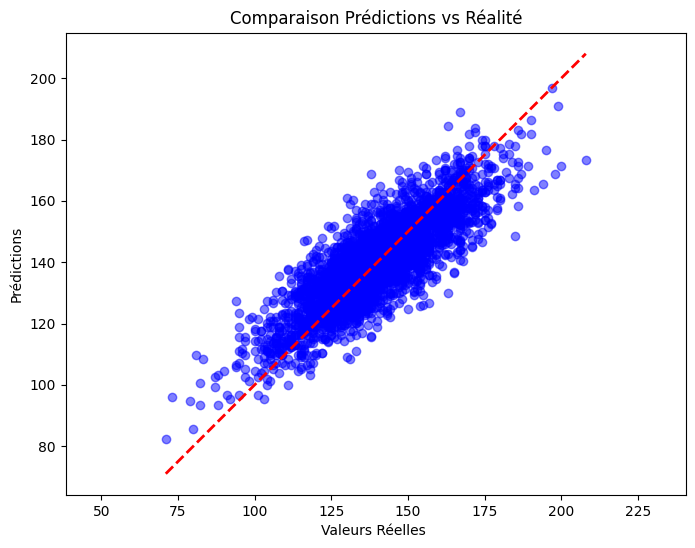

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test,best_predict, alpha=0.5, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles ')
plt.ylabel('Prédictions')
plt.title('Comparaison Prédictions vs Réalité')
plt.axis('equal')
plt.show()

 Le graphique montre une forte corrélation entre les valeurs réelles et les prédictions, le nuage de points suivant fidèlement la droite $y=x$, ce qui confirme la pertinence du modèle Lasso. On observe toutefois une légère tendance à la sous-estimation pour les valeurs de LDL les plus élevées (au-delà de 180), suggérant que le modèle est extrêmement fiable pour la majorité des patients mais perd un peu en précision sur les cas de cholestérol très sévère. Cette observation montre que les variables sélectionnées capturent bien la tendance générale, même si les valeurs extrêmes restent plus difficiles à prédire parfaitement

### Graphe des résidus

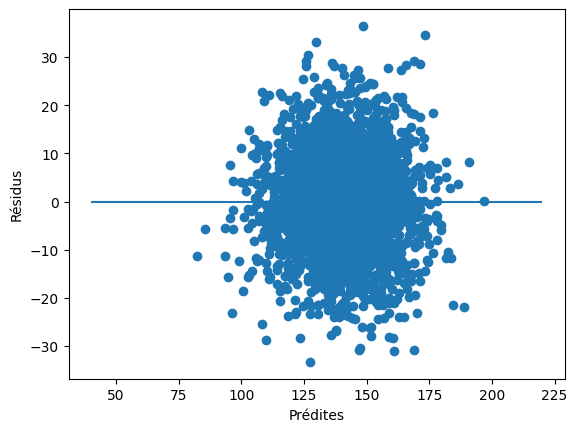

In [28]:
plt.plot(best_predict,Y_test-best_predict,"o")
plt.xlabel(u"Prédites")
plt.ylabel(u"Résidus")
plt.hlines(0,40,220)
plt.show()

Le graphique des résidus montre un nuage de points dispersé de manière aléatoire autour de zéro, sans forme particulière comme une "banane" ou une "trompette". Cette absence de structure valide l'hypothèse d'homoscédasticité, ce qui signifie que l'erreur du modèle est constante et ne dépend pas de la valeur prédite. Cette conclusion confirme la robustesse et la fiabilité de notre régression Lasso pour l'ensemble des données. Enfin nous étudions la MAE qui calcule l'écart moyen entre la prédiction et la valeur réelle.

In [29]:
mae = mean_absolute_error(Y_test, best_predict)
print(f"Erreur moyenne (MAE) : ",mae)

Erreur moyenne (MAE) :  7.717086699864803


Ici, la MAE est de $8.05$, ainsi cela signifie que les prédictions du taux de cholestérol LDL s'écartent en moyenne de plus ou moins $8.05$ unités des valeurs réelles observées sur le groupe de test. Enfin, nous traçons le chemin de régularisation pour visualiser comment les coefficients des variables s'annulent à mesure que la pénalité augmente, confirmant ainsi l'impact de notre alpha optimal de 0.13 sur la sélection finale.

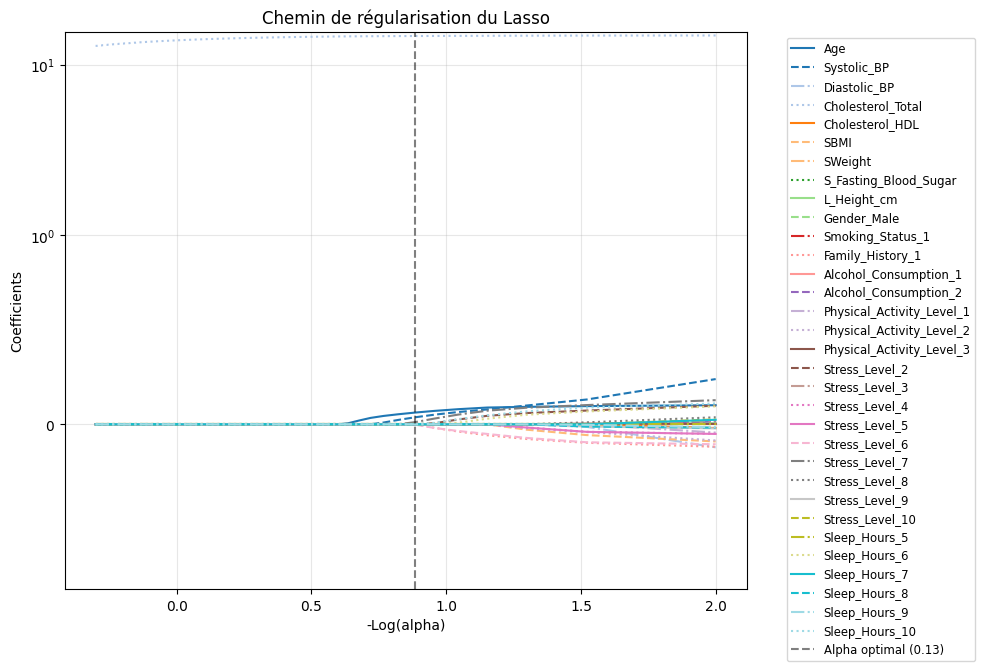

In [30]:
#echantillon d'alpha à tester
alphas_lasso, coefs_lasso, _ = lasso_path(X_train, Y_train, alphas=np.linspace(0.01, 2, 100))

plt.figure(figsize=(10, 7))
styles = cycle(['-', '--', '-.', ':'])

colors = plt.cm.tab20(np.linspace(0, 1, X_train.shape[1]))

neg_log_alphas_lasso = -np.log10(alphas_lasso)


for i in range(len(coefs_lasso)):
    plt.plot(neg_log_alphas_lasso, coefs_lasso[i], 
             label=X.columns[i],
             linestyle=next(styles), 
             color=colors[i])

alpha_opt = 0.13
plt.axvline(-np.log10(alpha_opt), linestyle='--', color='k', alpha=0.5, label=f'Alpha optimal ({alpha_opt})')
plt.yscale('symlog', linthresh=1)
plt.xlabel('-Log(alpha)')
plt.ylabel('Coefficients')
plt.title('Chemin de régularisation du Lasso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Légende à l'extérieur
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


On retrouve bien ce qu'on a vu précédemment le coefficients lié au cholesterol total est nettement plus grand que les autre qui sont proche de 0.

Nous allons passer au prochain algoritme qui est une SVR.

## SVR

### Kernel linéaire

Nous passons maintenant à la SVR (Support Vector Regression) pour modéliser notre variable quantitative. Comme pour la régression Lasso, nous optimisons les paramètres par validation croisée. Nous avons choisi un noyau linéaire (kernel linear) pour cette première étape, ce qui nous permettra de comparer directement les coefficients obtenus avec ceux de notre modèle précédent.

In [31]:
param_svr_lin = [
    {
        'kernel': ['linear'], 
        'C': [0.45,0.5,0.55,0.56,0.57,0.6],
        'epsilon': [0.01, 0.1, 0.5]
    }
]


grid_svr_lin = GridSearchCV(SVR(), param_svr_lin, cv=5, n_jobs=-1, scoring='r2')
SVRopt=grid_svr_lin.fit(X_train, Y_train)

print(f"Meilleur C : {grid_svr_lin.best_params_['C']}")
print(f"Meilleur R2 en validation croisée : {grid_svr_lin.best_score_:.4f}")


Meilleur C : 0.45
Meilleur R2 en validation croisée : 0.6850


In [32]:
predict_SVR=grid_svr_lin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR,Y_test), "MAE=", mean_absolute_error(Y_test,predict_SVR))

MSE= 96.10805888163092 MAE= 7.746366927970003


Pour le kernel linéaire, la SVR a une MSE de $103.3$ et une MAE de $8.06$. Regardons donc maintenant les coefficients de cette régression. 

In [33]:
best_svr_lin = grid_svr_lin.best_estimator_

coef_svr = pd.DataFrame({
    'Variable': X.columns, 
    'Coefficient': best_svr_lin.coef_[0]  # [0] car coef_ est une matrice 2D ici
})

# 3. Tri pour voir les variables les plus influentes
print(coef_svr.sort_values(by='Coefficient', ascending=False))

                     Variable  Coefficient
3           Cholesterol_Total    14.694673
5                        SBMI     0.739959
8                 L_Height_cm     0.580640
28              Sleep_Hours_7     0.322220
1                 Systolic_BP     0.320433
29              Sleep_Hours_8     0.286282
27              Sleep_Hours_6     0.277217
9                 Gender_Male     0.192070
0                         Age     0.178321
22             Stress_Level_7     0.141577
10           Smoking_Status_1     0.134231
7       S_Fasting_Blood_Sugar     0.124203
23             Stress_Level_8     0.117821
4             Cholesterol_HDL     0.108984
31             Sleep_Hours_10     0.093739
26              Sleep_Hours_5     0.089342
17             Stress_Level_2     0.071480
13      Alcohol_Consumption_2     0.065799
18             Stress_Level_3     0.057853
20             Stress_Level_5     0.056102
16  Physical_Activity_Level_3     0.012488
30              Sleep_Hours_9     0.010487
19         

On remarque que, tout comme pour la régression Lasso, le cholestérol total reste la variable la plus influente. Cependant, le modèle SVR accorde également une importance significative aux mesures corporelles telles que le poids (*SWeight*), l'IMC (*SBMI*) et la taille (*L_Height_cm*). Contrairement au Lasso qui avait annulé la plupart de ces variables, la SVR les conserve ici avec des coefficients non nuls, ce qui permet d'affiner la prédiction en tenant davantage compte de la morphologie du patient.

Nous allons maintenant tester des noyaux non linéaires, comme les kernels RBF et polynomial, pour voir s'ils surpassent le modèle linéaire. Ces méthodes permettent de capturer des relations plus complexes entre les variables que la simple régression. 

### Autres kernels

In [34]:
param_grid_SVR = [
    {

        'kernel': ['rbf'], 
        'C': [5.8,6,6.2,6.25,6.3], 
        'epsilon': [0.1, 0.05]
    },
    {

        'kernel': ['poly'], 
        'degree': [2,3], 
        'C': [1, 5],
        'epsilon': [0.1]
    }
]
grid_svr_nonlin = GridSearchCV(SVR(), param_grid_SVR, cv=5, scoring='r2', n_jobs=-1)
grid_svr_nonlin.fit(X_train, Y_train)

print(f"Meilleur Kernel : {grid_svr_nonlin.best_params_['kernel']}")
print(f"Paramètres optimaux : {grid_svr_nonlin.best_params_}")
print(f"Nouveau meilleur R2 : {grid_svr_nonlin.best_score_:.4f}")

Meilleur Kernel : rbf
Paramètres optimaux : {'C': 5.8, 'epsilon': 0.1, 'kernel': 'rbf'}
Nouveau meilleur R2 : 0.6526


In [35]:
predict_SVR_rbf=grid_svr_nonlin.predict(X_test)
print("MSE=",mean_squared_error(predict_SVR_rbf,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_SVR_rbf))

MSE= 106.32348626478682
MAE= 8.145178375523379


On remarque que les autres kernels n'améliorent pas la prédiction ($MSE=112.23$ et $R²=0.6637$) donc on ne va garder que le modèle avec kernel linéaire. Pour terminer, on va juste analyser le graphe des prédictions de la SVR en fonction des valeurs réelles.

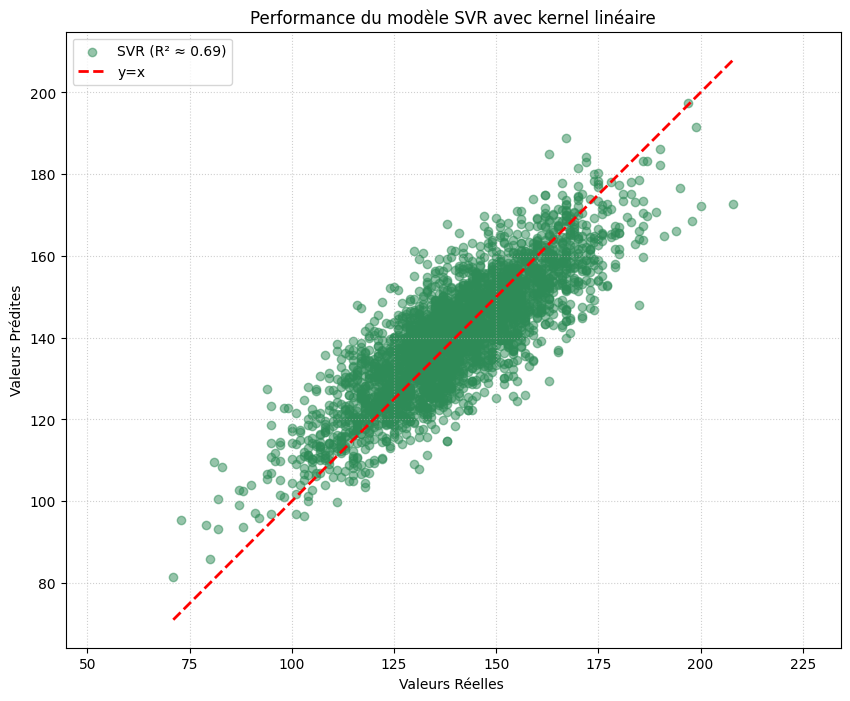

In [36]:
r2_svr = grid_svr_lin.best_score_

# 2. Création du graphique
plt.figure(figsize=(10, 8))

# Affichage des points du SVR
plt.scatter(Y_test, predict_SVR, alpha=0.5, color='seagreen', marker='o', label=f'SVR (R² ≈ {r2_svr:.2f})')

# 3. Ligne de perfection (y = x) pour bien voir l'alignement
lims = [min(Y_test.min(), predict_SVR.min()), max(Y_test.max(), predict_SVR.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

# 4. Habillage
plt.xlabel('Valeurs Réelles ')
plt.ylabel('Valeurs Prédites')
plt.title('Performance du modèle SVR avec kernel linéaire')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()


Le graphique montre que les points sont bien regroupés autour de la ligne rouge, ce qui prouve que le modèle SVR fonctionne bien. Il donne des résultats très proches de la régression Lasso. On remarque aussi comme pour Lasso que le modèle a un peu plus de mal à prédire les valeurs très hautes de cholestérol.

Nous avons terminé l'étude des régressions. Nous allons maintenant explorer une autre famille d'algorithmes : les arbres de décision.

## Arbre de décisions

### Random Forest

Nous commençons par l'algorithme des Forêts Aléatoires (Random Forest). Comme précédemment, nous utilisons la validation croisée pour déterminer les paramètres optimaux. Pour le nombre de variables à tester à chaque division (max_features), nous avons comparé trois options : la racine carrée du nombre total de variables, ainsi que le tiers de ce nombre (arrondi à l'entier inférieur et supérieur), afin de trouver le meilleur compromis pour notre modèle

In [37]:
p= X_train.shape[1] 

p_tiers = math.floor(p/3) 
p_tiers_sup = math.ceil(p/3)


param_grid_rf = {
    'max_features': [p_tiers, p_tiers_sup, 'sqrt'], # On teste p/3 vs les classiques
    'max_depth': [4,5,6,7,8,9, 10,11,12,13,14]
}
rf= GridSearchCV(RandomForestRegressor(n_estimators=200,criterion='squared_error'),
        param_grid_rf,cv=5,n_jobs=-1)
rfOpt=rf.fit(X_train, Y_train)


print("Meilleur score = %f, Meilleur paramètre = %s" % (rfOpt.best_score_,rfOpt.best_params_))


Meilleur score = 0.674530, Meilleur paramètre = {'max_depth': 14, 'max_features': 11}


In [38]:
predict_RF=rfOpt.predict(X_test)
print("MSE=",mean_squared_error(predict_RF,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_RF))

MSE= 99.31340091539892
MAE= 7.878610981400823


Les paramètres optimaux retenus sont une profondeur maximale de 11 et un sous-ensemble de 6 variables par division. Avec ces réglages, le modèle obtient une MSE de $106.51$ et une MAE de $8.17$. Nous allons maintenant analyser l'importance relative de chaque variable au sein de notre Forêt Aléatoire. Cela nous premettra de vérifier si le modèle s'appuie sur les mêmes variables clés que nos méthodes précédentes (Lasso et SVR).

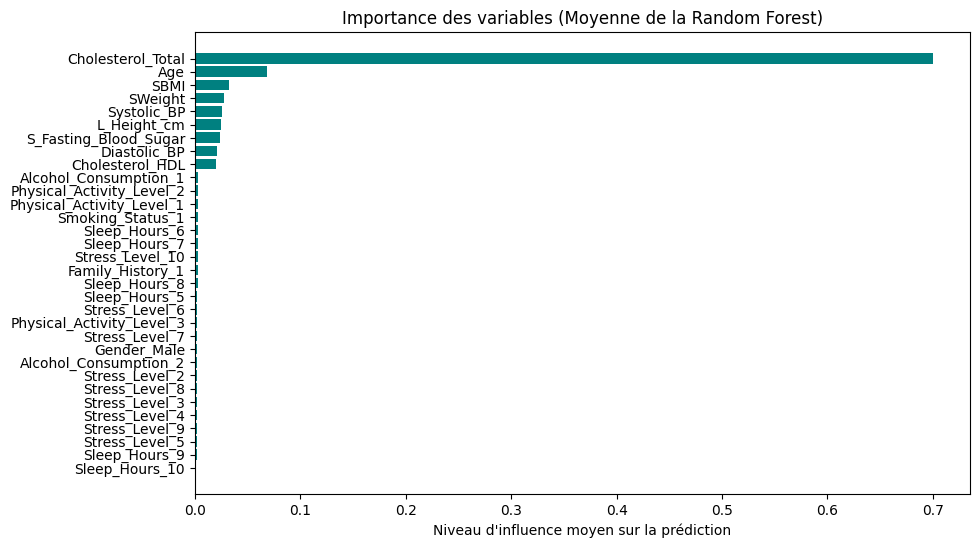

In [39]:
importances = rfOpt.best_estimator_.feature_importances_
labels = X.columns

df_importance = pd.DataFrame({'Variable': labels, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_importance['Variable'], df_importance['Importance'], color='teal')
plt.xlabel("Niveau d'influence moyen sur la prédiction")
plt.title("Importance des variables (Moyenne de la Random Forest)")
plt.show()

A nouveau, c'est le cholestérol total domine largement les prédictions, suivi de loin par l'âge et les indicateurs corporels (*SBMI*, *SWeight*). Cela confirme les résultats de nos modèles précédents : les facteurs biologiques sont nettement plus influent que le mode de vie (stress, sommeil, alcool) pour expliquer le taux de LDL.

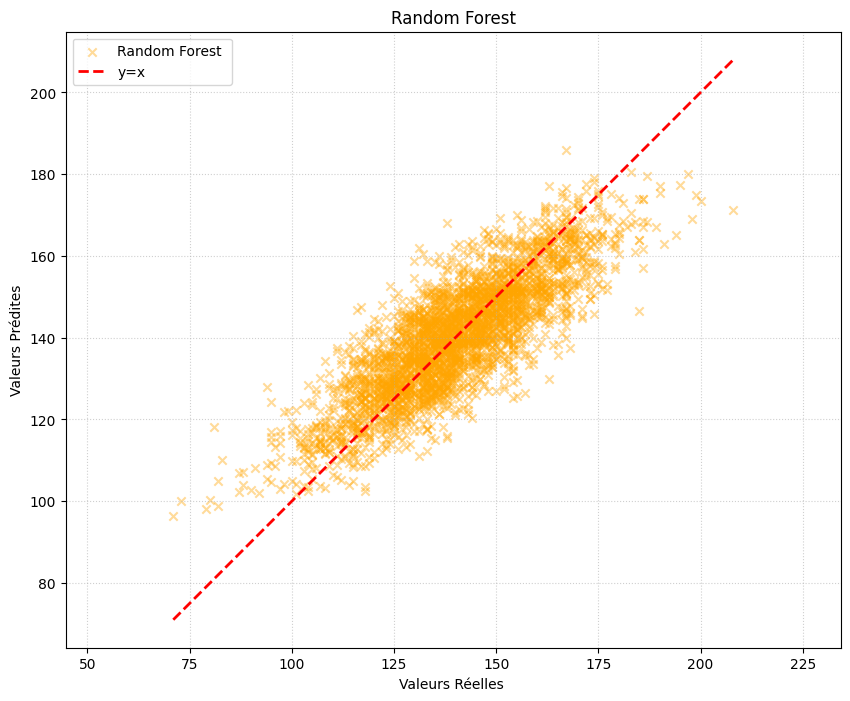

In [40]:
plt.figure(figsize=(10, 8))
plt.scatter(Y_test,predict_RF, alpha=0.4, color='orange', marker='x', label=f'Random Forest ')

lims = [min(Y_test.min(), predict_RF.min()), max(Y_test.max(), predict_RF.max())]
plt.plot(lims, lims, 'r--', lw=2, label='y=x')

plt.xlabel('Valeurs Réelles ')
plt.ylabel('Valeurs Prédites')
plt.title('Random Forest')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal')

plt.show()

Puisque les écarts de prédictions entre les modèles sont que légèrement différent on retrouve encore une fois la même conclusion sur lle graphe des valeurs prédites en fonctions des valeurs réelles. C'est à dire que de manière globale la recontruction est bonne mais pour le valeur plus grande de "mauvais cholestérol", la prédiction est moins bonne. 

Le prochain algorithme de cette famille est l'arbre de décision CART (Classification and Regression Trees).

## CART

Nous étudions à présent l'arbre de décision CART. Théoriquement, ce modèle devrait être moins performant que la Forêt Aléatoire, car il ne s'appuie que sur un seul arbre au lieu de faire la moyenne de plusieurs centaines pour stabiliser les prédictions. Cette étape nous permettra de voir si un modèle plus simple et plus lisible suffit à obtenir une précision satisfaisante.

In [41]:
param_cart = {
    'max_depth': [3,4, 5,6, 7, 10],
    'min_samples_leaf': [2,3,4,5,6,7,8,9,10],
    'criterion': ['squared_error', 'friedman_mse']
}


grid_cart = GridSearchCV(DecisionTreeRegressor(random_state=42), 
                         param_cart, cv=5, scoring='r2', n_jobs=-1)
cart_opt = grid_cart.fit(X_train, Y_train)

# 3. Prédictions et Scores
predict_cart = cart_opt.predict(X_test)

print(f"Meilleurs paramètres CART : {cart_opt.best_params_}")
print(f"R² CART : {r2_score(Y_test, predict_cart):.4f}")


Meilleurs paramètres CART : {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 10}
R² CART : 0.6877


In [42]:

print("MSE=",mean_squared_error(predict_cart,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_cart))

MSE= 97.83877688043233
MAE= 7.804876855471855


Étonnamment, ce modèle obtient une erreur quadratique moyenne plus faible que la Forêt Aléatoire ($MSE = 104.91$ contre $106.51$). Cependant, le coefficient de détermination ($R²$) reste supérieur pour la Forêt Aléatoire. Cette différence s'explique par le fait que la MSE est très sensible aux erreurs importantes, tandis que le $R²$ évalue mieux la capacité globale du modèle à expliquer la variance totale des données.

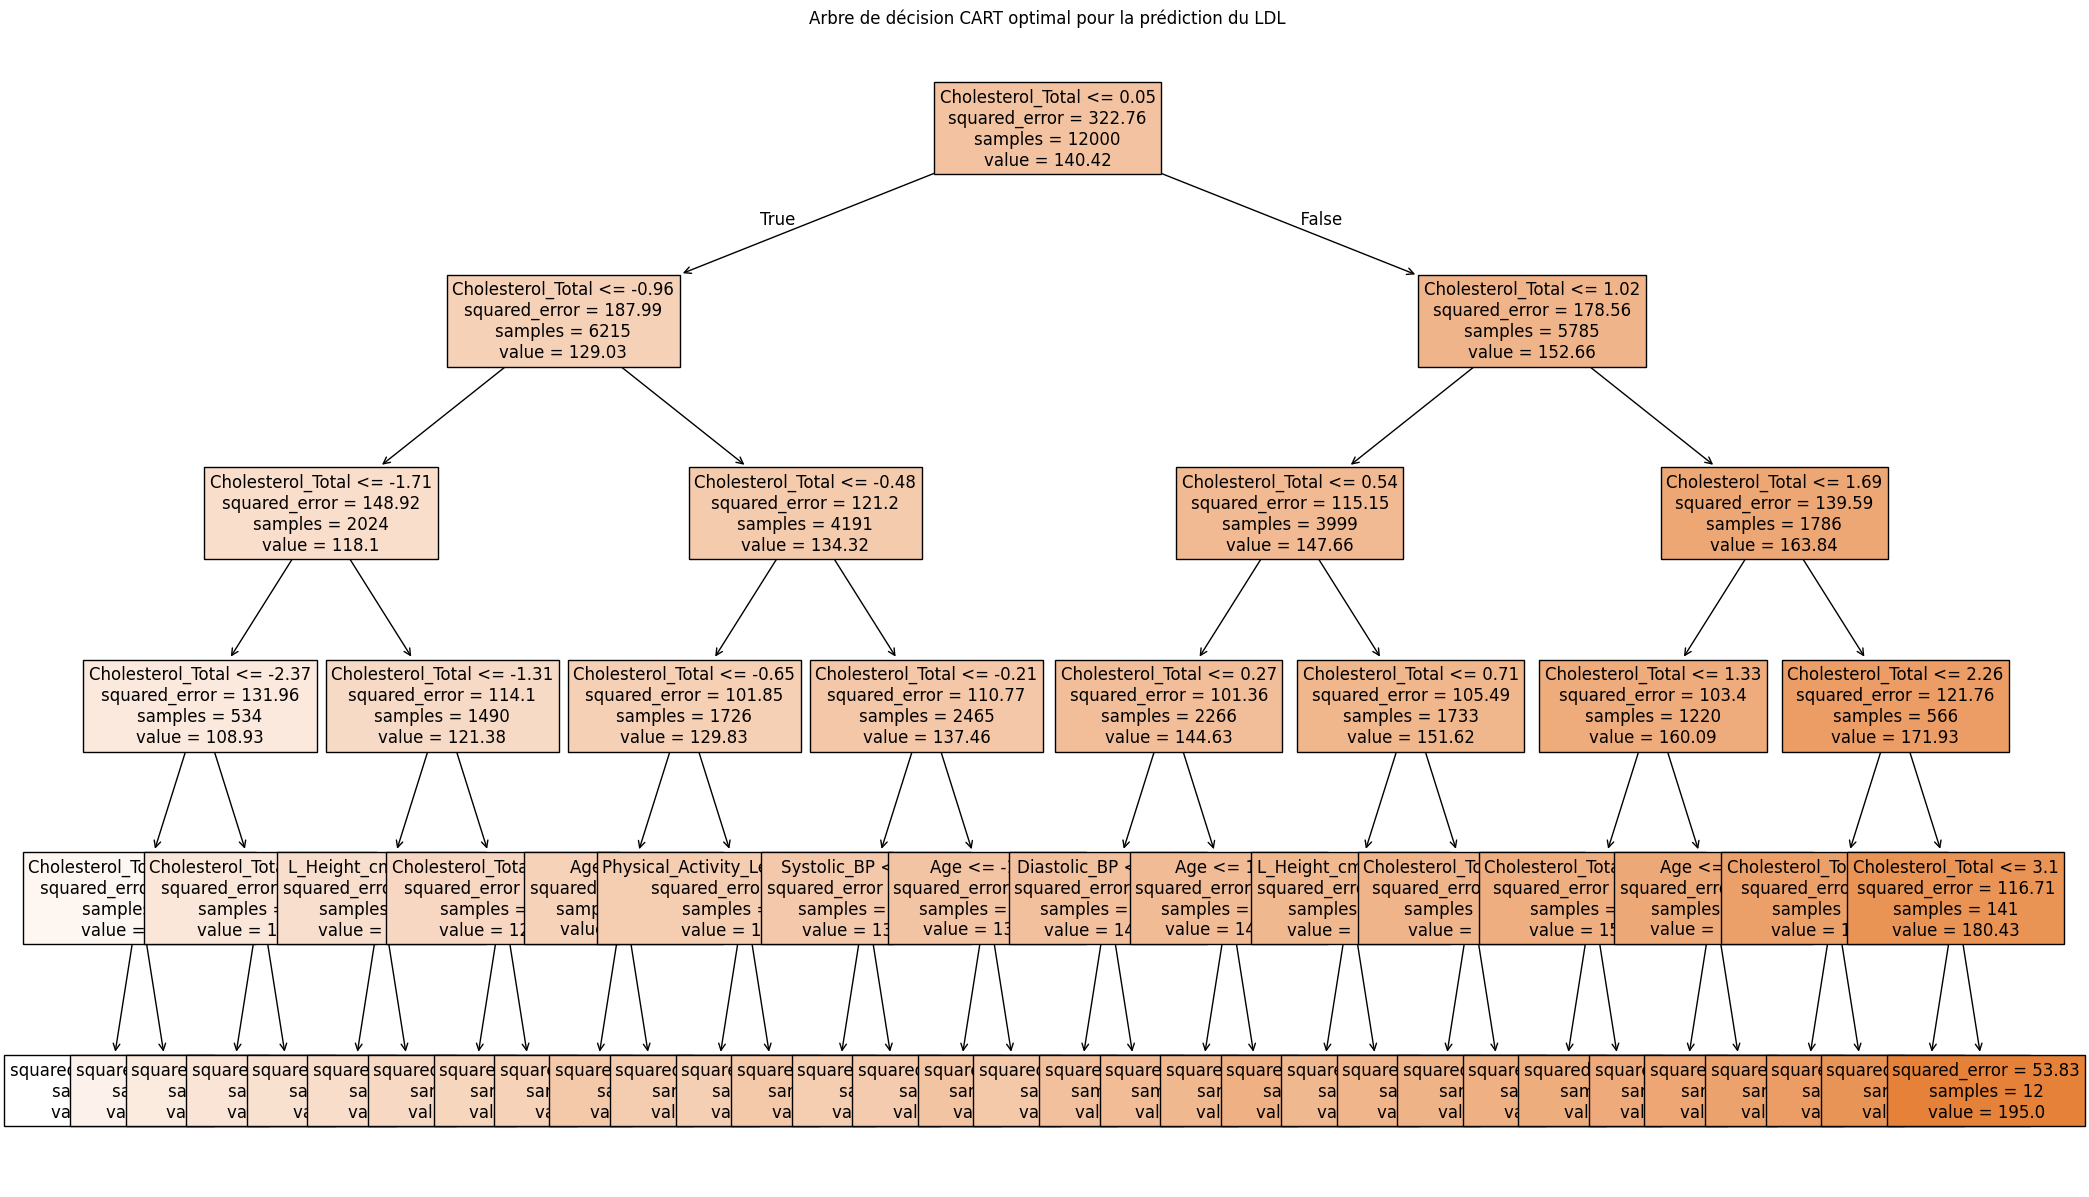

In [43]:
plt.figure(figsize=(25, 15))
tree.plot_tree(cart_opt.best_estimator_, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12,
               precision=2)
plt.title("Arbre de décision CART optimal pour la prédiction du LDL")
plt.show()

La lecture de l'arbre confirme que le cholestérol total constitue le facteur discriminant le plus important, puisqu'il est sélectionné pour la première division à la racine. On observe ensuite les autres facteurs sont l'âge et des variables morphologiques comme le poids ou l'IMC. 

Après avoir étudié les arbres simples et les forêts aléatoires, nous allons maintenant explorer le **Boosting**.

# Boosting

Dans la cellule suivante, nous allons mettre en œuvre un modèle de Gradient Boosting. Comme pour les méthodes précédentes, nous optimisons les hyperparamètres par validation croisée. Les valeurs testées ici ont été choisies empiriquement afin de cibler au mieux la combinaison optimale.

In [44]:
param_boost = {
    'learning_rate': [0.02,0.03,0.04,0.05], 
    'max_depth': [2,3, 4, 5,6],
    'subsample': [0.04,0.05,0.6,0.7,0.8],
    'n_estimators': [50, 100, 200],

}

grid_boost = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                          param_boost, cv=5, scoring='r2', n_jobs=-1)
boost_opt = grid_boost.fit(X_train, Y_train)

print(f"Meilleur R² Boosting : {boost_opt.best_score_:.4f}")
print(f"Paramètres : {boost_opt.best_params_}")


Meilleur R² Boosting : 0.6843
Paramètres : {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.6}


In [45]:
predict_boost = boost_opt.predict(X_test)
print("MSE=",mean_squared_error(predict_boost,Y_test))
print("MAE=",mean_absolute_error(Y_test, predict_boost))


MSE= 96.2676740791857
MAE= 7.749948186826926


Le modèle optimal retient une profondeur maximale de 2 ($max_depth=2$). On obtient alors un $R^2$ de $0.6888$ et une erreur quadratique moyenne (MSE) de $103.56$. Afin d'obtenir une première représentation visuelle de la structure du modèle, le premier arbre de la forêt de boosting est affiché dans la cellule suivante.

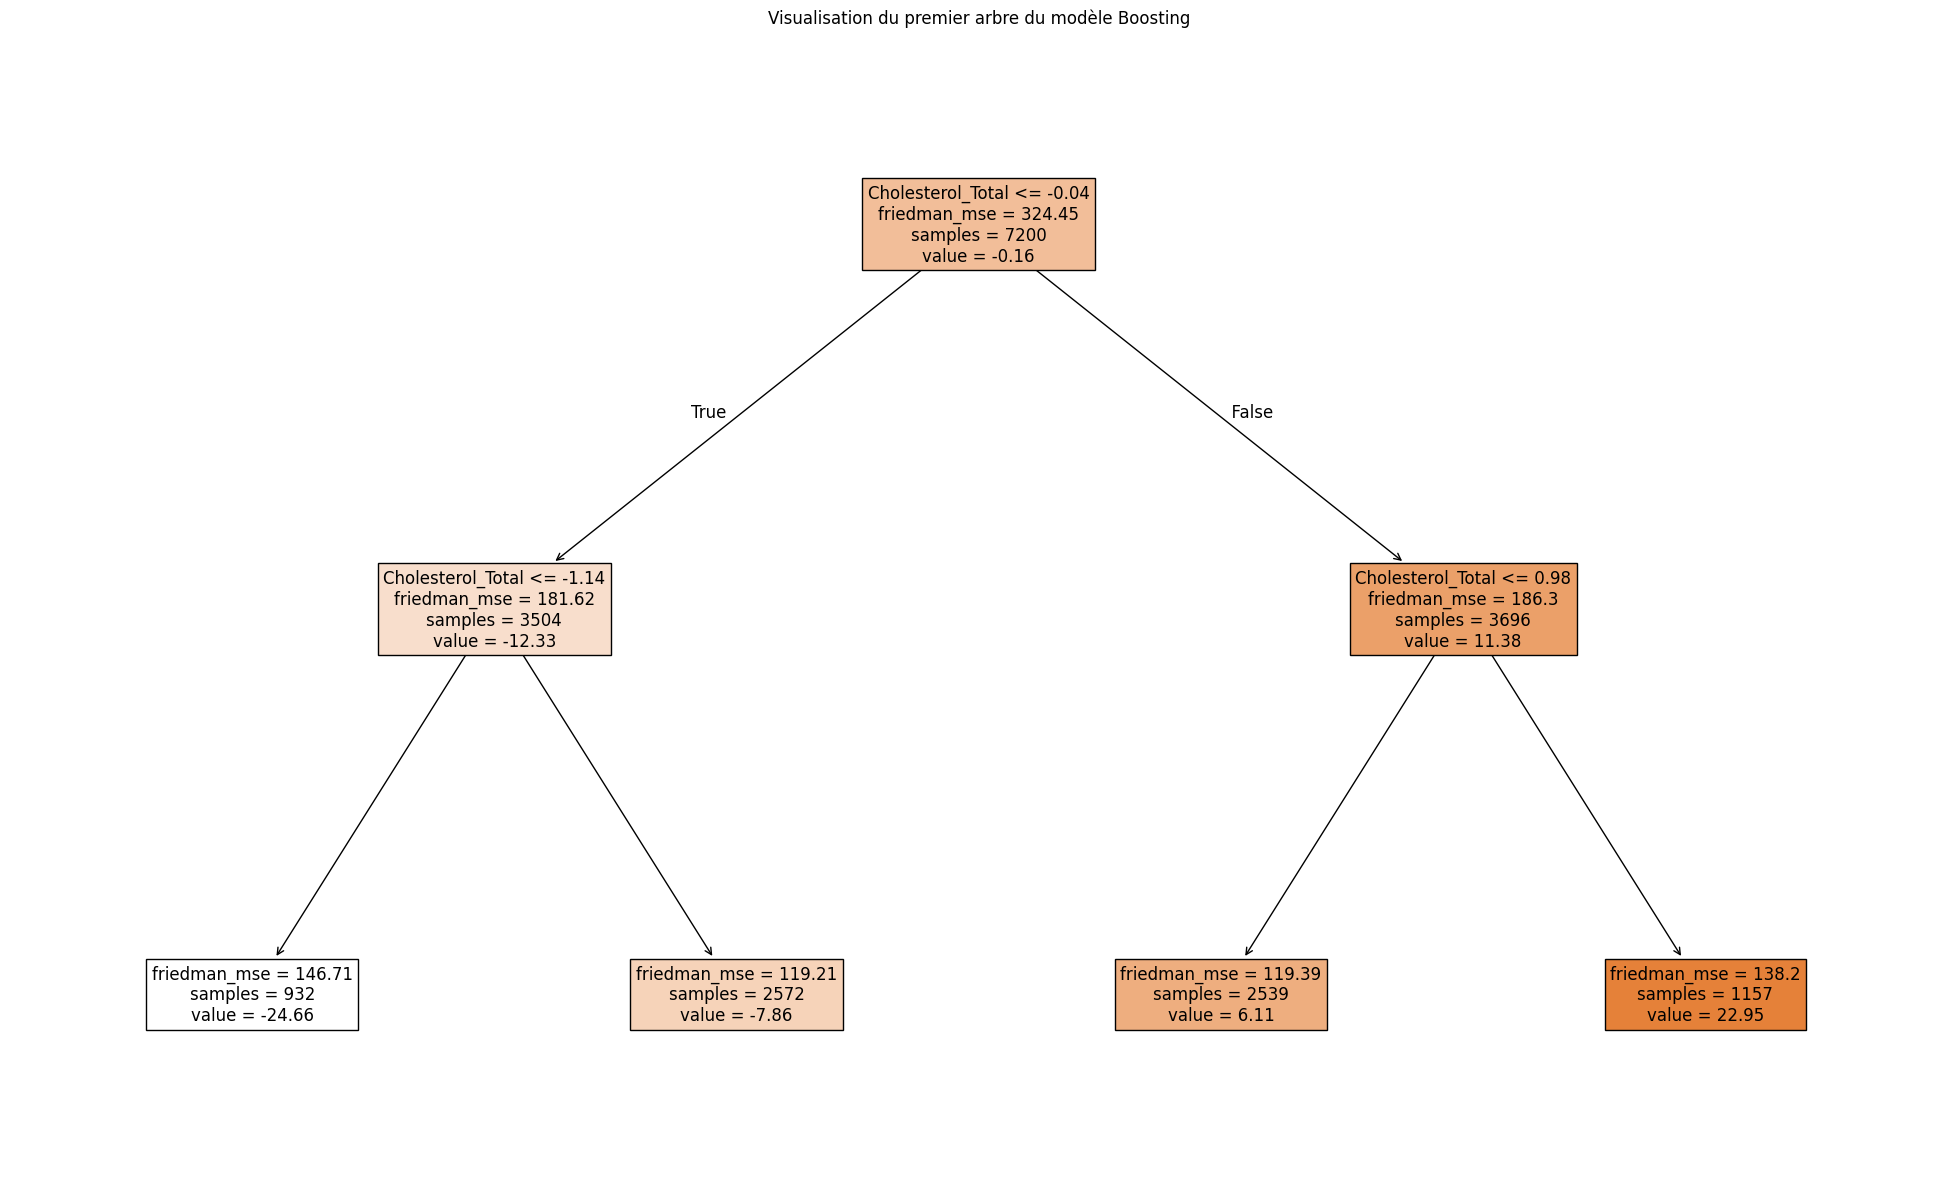

In [46]:
plt.figure(figsize=(25, 15))

# On accède au premier arbre de la forêt de boosting

tree_to_plot = boost_opt.best_estimator_.estimators_[0, 0]

tree.plot_tree(tree_to_plot, 
               feature_names=X.columns, 
               filled=True, 
               fontsize=12,
               precision=2)

plt.title("Visualisation du premier arbre du modèle Boosting")
plt.show()

Ce premier arbre confirme visuellement le choix des hyperparamètres avec une profondeur maximale de 2 (max_depth=2). On constate que le Cholesterol_Total est la seule variable utilisée pour scinder les données à chaque nœud, confirmant son rôle de facteur discriminant majeur.

Les valeurs numériques observées dans les feuilles (allant de $-24.54$ à $+24.10$) ne représentent pas ici le taux de cholestérol LDL final, mais des résidus (ou corrections) que l'algorithme va faire. Fidèle au principe du Gradient Boosting, ce premier arbre applique une première correction positive ou négative à la moyenne globale des patients. Celle-ci sera ensuite affinée par l'action successive et cumulative des 199 arbres suivants, chacun multiplié par le taux d'apprentissage ($learningrate = 0.03$).

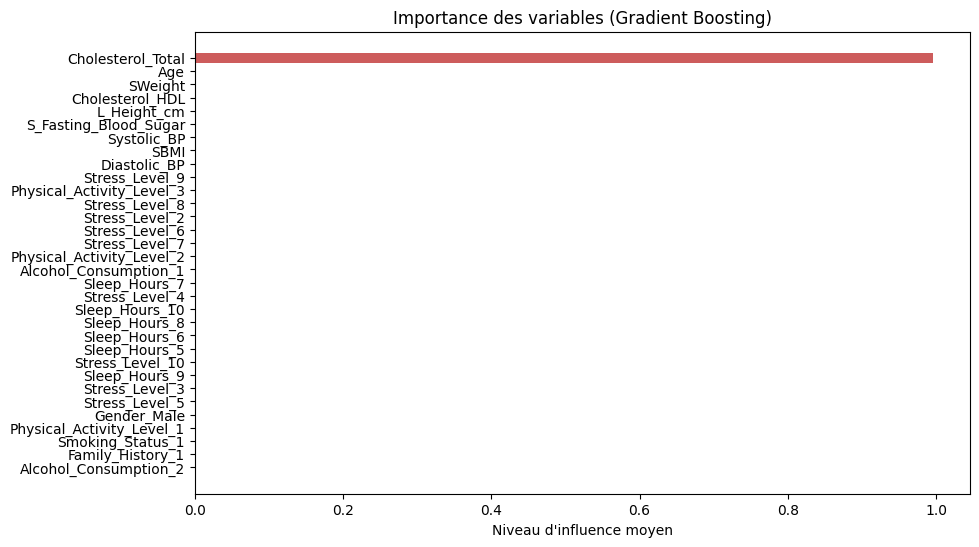

In [47]:
importances_boost = boost_opt.best_estimator_.feature_importances_
df_imp_boost = pd.DataFrame({'Variable': X.columns, 'Importance': importances_boost})
df_imp_boost = df_imp_boost.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_imp_boost['Variable'], df_imp_boost['Importance'], color='indianred')
plt.xlabel("Niveau d'influence moyen")
plt.title("Importance des variables (Gradient Boosting)")
plt.show()

Le graphique de l’importance des variables révèle un comportement très polarisé du **Gradient Boosting**. Contrairement à la Forêt Aléatoire qui distribuait une partie de son attention à l'âge ou aux critères morphologiques (comme le poids), le Boosting concentre la quasi-totalité de son importance (proche de 100 %) sur une seule variable : le *Cholesterol_Total*.

Si le graphique de l'importance des variables met en évidence la structure des décisions du modèle, il est essentiel de s'assurer que cette focalisation extrême sur le cholestérol ne conduit pas à du surapprentissage. C'est ce que permet de vérifier l'analyse de l'évolution de l'erreur afficher dans la cellule suivante.

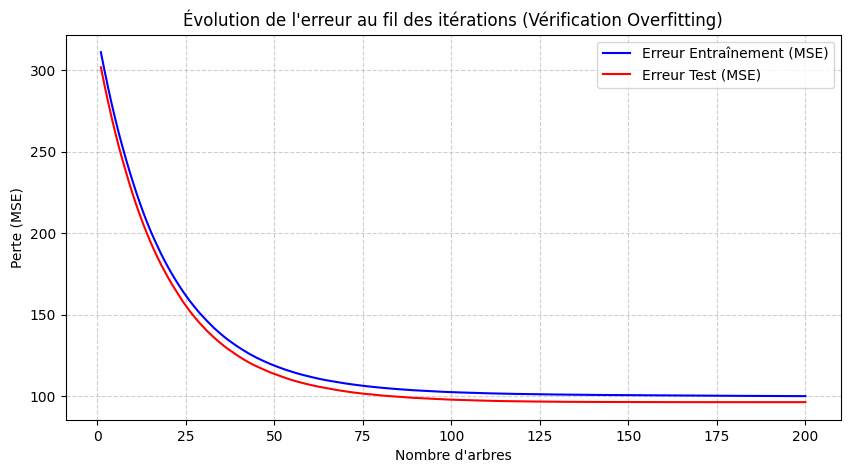

In [48]:
# 1. On récupère le nombre d'arbres final
n_trees = boost_opt.best_estimator_.n_estimators

# 2. On calcule la MSE sur le Test à chaque étape
test_score = np.zeros((n_trees,), dtype=np.float64)
for i, y_pred in enumerate(boost_opt.best_estimator_.staged_predict(X_test)):
    test_score[i] = mean_squared_error(Y_test, y_pred)

# 3. On calcule la MSE sur l'Entraînement à chaque étape
train_score = np.zeros((n_trees,), dtype=np.float64)
for i, y_pred in enumerate(boost_opt.best_estimator_.staged_predict(X_train)):
    train_score[i] = mean_squared_error(Y_train, y_pred)

# 4. Affichage du graphique
plt.figure(figsize=(10, 5))
plt.plot(np.arange(n_trees) + 1, train_score, 'b-', label='Erreur Entraînement (MSE)')
plt.plot(np.arange(n_trees) + 1, test_score, 'r-', label='Erreur Test (MSE)')
plt.ylabel('Perte (MSE)')
plt.xlabel('Nombre d\'arbres')
plt.title('Évolution de l\'erreur au fil des itérations (Vérification Overfitting)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Le graphique d'Évolution de l'erreur confirme l'absence totale de surapprentissage.

Les courbes d'entraînement (bleu) et de test (rouge) diminuent de manière synchrone avant de se stabiliser ensemble à partir de 100 arbres. La courbe de test ne remonte jamais, prouvant une excellente capacité de généralisation.

Ce comportement idéal valide les choix de notre validation croisée : la faible profondeur ($maxdepth=2$) et le sous-échantillonnage ($subsample=0.6$) ont parfaitement régularisé le modèle.

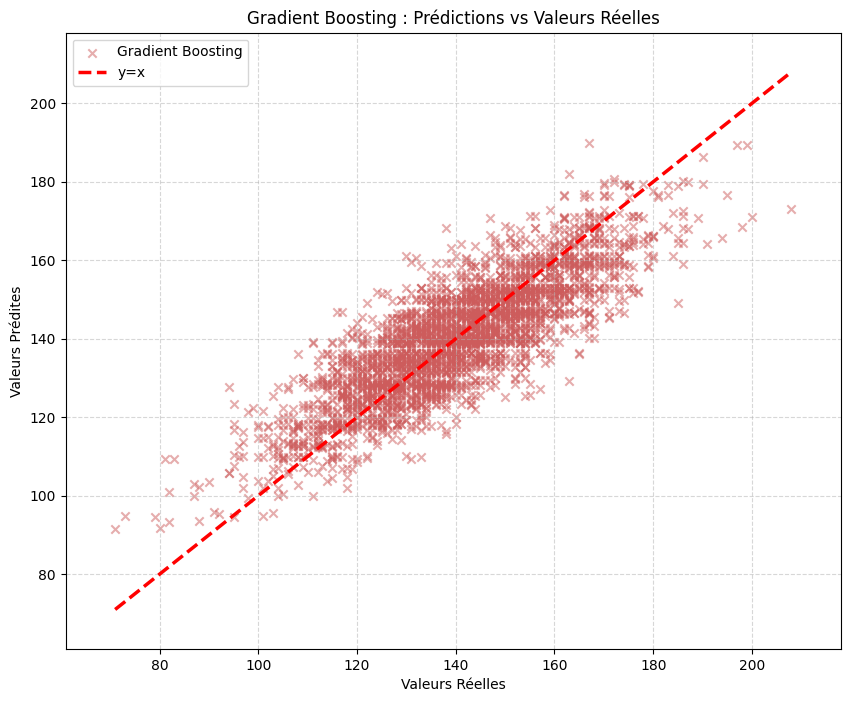

In [49]:

predict_boost = boost_opt.predict(X_test)

# 2. Configuration et tracé du graphique
plt.figure(figsize=(10, 8))

# Nuage de points (on utilise une couleur brique/marron pour changer de la RF)
plt.scatter(Y_test, predict_boost, color='indianred', alpha=0.5, marker='x', label=f"Gradient Boosting")

# Ligne idéale y = x
max_val = max(max(Y_test), max(predict_boost))
min_val = min(min(Y_test), min(predict_boost))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='y=x')

# Habillage du graphique
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title('Gradient Boosting : Prédictions vs Valeurs Réelles')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

# Ajustement des axes pour qu'ils soient lisibles
plt.xlim(min_val - 10, max_val + 10)
plt.ylim(min_val - 10, max_val + 10)

plt.show()

Le graphique confirme que le Gradient Boosting suit la même tendance globale que nos modèles précédents. Bien que le nuage de points soit nettement plus resserré autour de la droite idéale $y=x$, on retrouve le même défaut structurel : le modèle sous-estime systématiquement les valeurs réelles les plus élevées. Dès que le taux réel dépasse $180$, les prédictions sont moins bonnes et sous-estiment la valeur réelle, confirmant la difficulté commune à tous nos algorithmes à modéliser précisément les profils extrêmes.

En conclusion sur les modèles arborescents, le Gradient Boosting s'impose comme le plus performant ($R^2 \approx 0,69$). Néanmoins, tous ces précédentes méthodes partagent la même conclusion: une dépendance exclusive au *Cholestérol total*.

Pour finir nous allons implémenter la dernière methode appartenant à la famille de réseaux de neurones, ce sont les *MLPRegressor*.

# Réseaux de neurones

In [50]:

param_grid = [{"hidden_layer_sizes": [(5,), (6,), (7,), (8,)]}]

nnet = GridSearchCV(MLPRegressor(max_iter=1000), param_grid, cv=10, n_jobs=-1)

nnetOpt = nnet.fit(X_train, Y_train)

print("Meilleur R² (CV)   = %.4f" % nnetOpt.best_score_)
print("Meilleur paramètre = %s" % nnetOpt.best_params_)


Meilleur R² (CV)   = 0.6765
Meilleur paramètre = {'hidden_layer_sizes': (7,)}


In [51]:
y_chap = nnetOpt.predict(X_test)

# Calcul de vos métriques habituelles
r2_test = r2_score(Y_test, y_chap)
mse_test = mean_squared_error(Y_test, y_chap)
mae_test = mean_absolute_error(Y_test, y_chap)


print(f"R² (Test)  : {r2_test:.4f}")
print(f"MSE (Test) : {mse_test:.4f}")
print(f"MAE (Test) : {mae_test:.4f}")

R² (Test)  : 0.6829
MSE (Test) : 99.3679
MAE (Test) : 7.8443


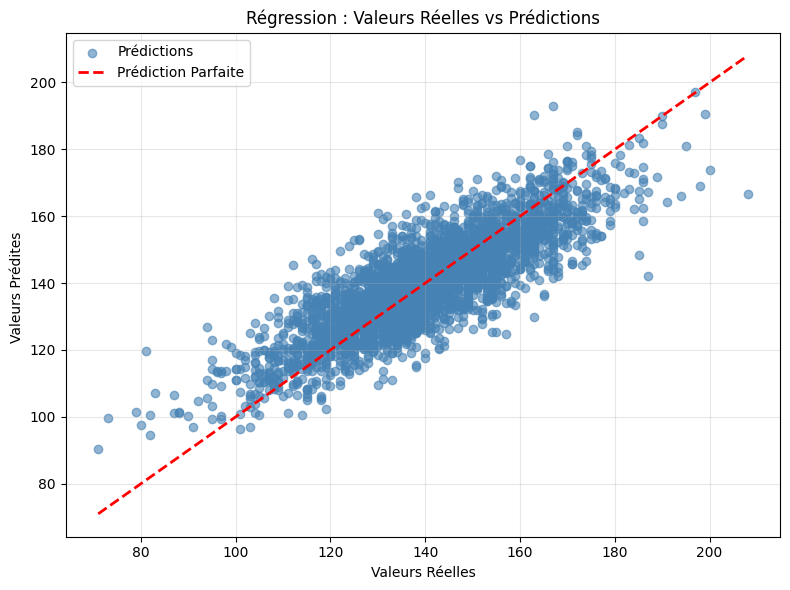

In [52]:

plt.figure(figsize=(8, 6))

# Nuage de points : Valeurs Réelles vs Prédictions
plt.scatter(Y_test, y_chap, color='steelblue', alpha=0.6, label='Prédictions')

# Ligne de perfection (y = x)
# L'équivalent de la diagonale parfaite d'une matrice de confusion !
min_val = min(Y_test.min(), y_chap.min())
max_val = max(Y_test.max(), y_chap.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Prédiction Parfaite')

plt.title('Régression : Valeurs Réelles vs Prédictions')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparaison des modèles

Maintenant que nous venons d'entrainer et de tester chaque méthode sur notre jeu de données, nous allons les comparer en prenant comme critères la MSE et le score R².

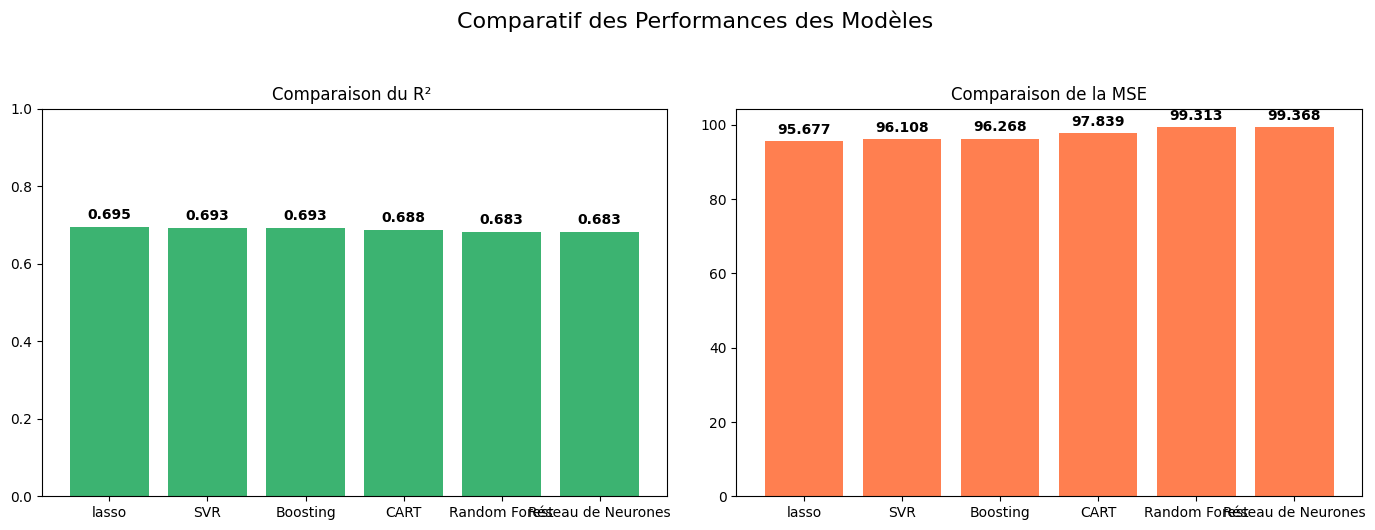

In [54]:
modeles_a_comparer = {
    "Random Forest": rfOpt,
    "Réseau de Neurones": nnetOpt,
     "lasso": regLassOpt,
    "SVR": SVRopt,
    "CART":cart_opt,
    "Boosting":boost_opt
}

scores_r2 = {}
scores_mse = {}
predictions = {}

# 2. Calcul des prédictions et des métriques pour chaque modèle
for nom, modele in modeles_a_comparer.items():
    # Prédiction sur le jeu de test
    y_pred = modele.predict(X_test)
    predictions[nom] = y_pred
    
    # Calcul des métriques
    scores_r2[nom] = r2_score(Y_test, y_pred)
    scores_mse[nom] =mean_squared_error(Y_test, y_pred)


n_modeles = len(modeles_a_comparer)
noms_modeles = list(modeles_a_comparer.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#dictionnaire ordonné du score R² de chaque méthode
r2_tries = dict(sorted(scores_r2.items(), key=lambda item: item[1], reverse=True))
noms_r2 = list(r2_tries.keys())
valeurs_r2 = list(r2_tries.values())

ax1.bar(noms_r2, valeurs_r2, color='mediumseagreen')
ax1.set_title('Comparaison du R² ', fontsize=12)
ax1.set_ylim(0, 1) 
for i, v in enumerate(valeurs_r2):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')


#dictionnaire ordonné du MSE de chaque méthode
mse_tries = dict(sorted(scores_mse.items(), key=lambda item: item[1]))
noms_mse = list(mse_tries.keys())
valeurs_mse = list(mse_tries.values())

ax2.bar(noms_mse, valeurs_mse, color='coral')
ax2.set_title('Comparaison de la MSE', fontsize=12)
for i, v in enumerate(valeurs_mse):
    ax2.text(i, v + (max(valeurs_mse) * 0.02), f"{v:.3f}", ha='center', fontweight='bold')
plt.suptitle("Comparatif des Performances des Modèles", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

En conclusion, les différentes méthodes testées aboutissent à des performances globales très similaires, sans qu'aucun modèle ne se démarque de façon significative dans ses prédictions. On peut toutefois noter que la régression linéaire avec pénalisation Lasso offre de très légers avantages : elle présente en effet l'erreur quadratique moyenne (MSE) la plus faible de notre étude, couplée au coefficient de détermination (R²) le plus élevé.